# Ventanas de riesgo en Nueva York
### Entendimiento del negocio y de los datos

---
**Pontificia Universidad Javeriana**

**Facultad de Ingeniería**

**Materia:** Procesamiento de Datos a Gran Escala

**Número de Clase:** 1055 

**Profesor**: John Jairo Corredor Franco

**Integrantes del Equipo:** 
- Monica Maria Castro Benitez -  ID 00020574755
- Lorenzo Ramírez Calderón -  ID 00020550074
- Gabriela Alejandra Muñoz Tovar - ID 00020567575
- Luis Alexander Pedraza - ID 00020531526

**Fecha:** 2-10-2026

---


## 1. Configuración del entorno

In [1]:
# Instalación de dependencias
!pip install numpy pandas scikit-learn seaborn matplotlib pyarrow tabulate --quiet

In [2]:
# Importación de librerías, Apache Spark Libraries
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Librerías 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [3]:
# Building Spark Session
spark = (SparkSession.builder
                  .appName('ProyectoNY')
                  .config("spark.executor.memory", "1G")
                  .config("spark.executor.cores","4")
                  .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [4]:
# Imprimir solo advertencias y errores
spark.sparkContext.setLogLevel('WARN')

In [5]:
# Características del entorno
print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)
print("Paralelismo por defecto:", spark.sparkContext.defaultParallelism)
print("Sistema de archivos:", spark.sparkContext._jsc.hadoopConfiguration().get("fs.defaultFS"))
print("Memoria por executor:", spark.conf.get("spark.executor.memory"))
print("Núcleos por executor:", spark.conf.get("spark.executor.cores"))

Spark: 4.0.4
Master: local[*]
Paralelismo por defecto: 4
Sistema de archivos: file:///
Memoria por executor: 1G
Núcleos por executor: 4


## 2. Carga de los Datasets

Los datasets utilizados representan diferentes dimensiones asociadas al riesgo urbano: criminalidad (arrestos y denuncias), seguridad vial (siniestros), condiciones socioeconómicas (pobreza), condiciones ambientales (clima) y población.

Esta combinación permite analizar el riesgo desde una perspectiva temporal, espacial y contextual, evitando interpretar los conteos absolutos sin considerar el tamaño de la población de cada borough.


In [6]:
# Cargar base de datos de arrestos
url = '/opt/cluster/proyecto_ny/data/raw/arrests.csv'
arrests_raw = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema","true")\
       .load(url) 

# Cargar base de datos de colisiciones
url = '/opt/cluster/proyecto_ny/data/raw/vehicle_collisions_crashes.csv'
crashes_raw = (spark.read.format("csv")
       .option("header", "true")
       .option("inferSchema", "true")
       .option("multiLine", "true")
       .option("escape", '"')
       .load(url))

# Cargar base de datos de historial de reclamaciones
url = '/opt/cluster/proyecto_ny/data/raw/complaint_data_history.csv'
complaints_raw = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema","true")\
       .load(url)

# Cargar base de datos de indice de pobreza
url = '/opt/cluster/proyecto_ny/data/raw/proverty_measure.csv'
poverty_raw = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema","true")\
       .load(url)

# Cargar base de datos de clima en formato Parquet
url = '/opt/cluster/proyecto_ny/data/raw/clima_nyc.parquet'
weather_raw = spark.read.parquet(url)

# Cargar base de datos de población por borough
url = '/opt/cluster/proyecto_ny/data/raw/population_boroughs.csv'
population_raw = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema","true")\
       .load(url)


In [7]:
# Verificar los datasets cargados
print(f"Arrests: {arrests_raw.head()}")
print(f"\nCrashes: {crashes_raw.head()}")
print(f"\nComplaints: {complaints_raw.head()}")
print(f"\nPoverty Measure: {poverty_raw.head()}")
print(f"\nWather: {weather_raw.head()}")
print(f"\nPopulation: {population_raw.head()}")

Arrests: Row(ARREST_KEY=318203929, ARREST_DATE='12/31/2025', PD_CD=439, PD_DESC='LARCENY,GRAND FROM OPEN AREAS, UNATTENDED', KY_CD=109, OFNS_DESC='GRAND LARCENY', LAW_CODE='PL 1553501', LAW_CAT_CD='F', ARREST_BORO='M', ARREST_PRECINCT=18, JURISDICTION_CODE=0, AGE_GROUP='25-44', PERP_SEX='M', PERP_RACE='BLACK', X_COORD_CD=991530.0, Y_COORD_CD=217373.0, Latitude='40,763321', Longitude='-73,973718', Lon_Lat='POINT (-73.973718 40.763321)')

Crashes: Row(CRASH DATE='09/11/2021', CRASH TIME=datetime.datetime(2026, 10, 2, 2, 39), BOROUGH=None, ZIP CODE=None, LATITUDE=None, LONGITUDE=None, LOCATION=None, ON STREET NAME='WHITESTONE EXPRESSWAY', CROSS STREET NAME='20 AVENUE', OFF STREET NAME=None, NUMBER OF PERSONS INJURED=2, NUMBER OF PERSONS KILLED=0, NUMBER OF PEDESTRIANS INJURED=0, NUMBER OF PEDESTRIANS KILLED=0, NUMBER OF CYCLIST INJURED=0, NUMBER OF CYCLIST KILLED=0, NUMBER OF MOTORIST INJURED=2, NUMBER OF MOTORIST KILLED=0, CONTRIBUTING FACTOR VEHICLE 1='Aggressive Driving/Road Rage', CON

26/10/02 17:56:51 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



Complaints: Row(CMPLNT_NUM='318168948', CMPLNT_FR_DT='12/31/2025', CMPLNT_FR_TM='00:23:00', CMPLNT_TO_DT=None, CMPLNT_TO_TM='(null)', ADDR_PCT_CD=113, RPT_DT='12/31/2025', KY_CD=250, OFNS_DESC='CANNABIS RELATED OFFENSES', PD_CD=579, PD_DESC='CANNABIS POSSESSION, 2&1', CRM_ATPT_CPTD_CD='COMPLETED', LAW_CAT_CD='FELONY', BORO_NM='QUEENS', LOC_OF_OCCUR_DESC='(null)', PREM_TYP_DESC='AIRPORT TERMINAL', JURIS_DESC='PORT AUTHORITY', JURISDICTION_CODE=3, PARKS_NM='(null)', HADEVELOPT='(null)', HOUSING_PSA='(null)', X_COORD_CD='1.042.801', Y_COORD_CD=181.715, SUSP_AGE_GROUP='25-44', SUSP_RACE='WHITE', SUSP_SEX='M', TRANSIT_DISTRICT=None, Latitude='40,66524878', Longitude='-73,78894843', Lat_Lon='(40.66524878, -73.78894843)', PATROL_BORO='PATROL BORO QUEENS SOUTH', STATION_NAME='(null)', VIC_AGE_GROUP='UNKNOWN', VIC_RACE='UNKNOWN', VIC_SEX='E')

Poverty Measure: Row(SERIALNO=1, SPORDER=1, PWGTP=95.0, WGTP=95.0, AGEP=31, CIT=1, REL=0, SCH=1, SCHG=0, SCHL=22, SEX=2, ESR=1, LANX=2, ENG=None, MSP=6,

## 3. Descripción de los datos


### Conteo de registros

In [8]:
# Conteo de registros de cada dataset
print("Arrests: ", arrests_raw.count())
print("Crashes: ", crashes_raw.count())
print("Complaints: ", complaints_raw.count())
print("Poverty: ", poverty_raw.count())
print("Weather: ", weather_raw.count())
print("Population: ", population_raw.count())

Arrests:  6264978


Crashes:  2269187


Complaints:  10071507
Poverty:  68273
Weather:  601320
Population:  5


### Tipo de Datos y Esquemas

In [9]:
# Tipo de datos y esquemas, descripción general del contenido de los datasets

print("--- Esquema Arrestos ---")
arrests_raw.printSchema()

print("--- Muestra Arrestos ---")
#arrests.show(5, truncate=False) 
arrests_raw.limit(5).toPandas() # Permite un esquema más fácil de leer

--- Esquema Arrestos ---
root
 |-- ARREST_KEY: integer (nullable = true)
 |-- ARREST_DATE: string (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- LAW_CODE: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- ARREST_BORO: string (nullable = true)
 |-- ARREST_PRECINCT: integer (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- AGE_GROUP: string (nullable = true)
 |-- PERP_SEX: string (nullable = true)
 |-- PERP_RACE: string (nullable = true)
 |-- X_COORD_CD: double (nullable = true)
 |-- Y_COORD_CD: double (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Lon_Lat: string (nullable = true)

--- Muestra Arrestos ---


,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,318203929,12/31/2025,439,"LARCENY,GRAND FROM OPEN AREAS, UNATTENDED",109,GRAND LARCENY,PL 1553501,F,M,18,0,25-44,M,BLACK,991530.0,217373.0,"40,763321","-73,973718",POINT (-73.973718 40.763321)
1,318208177,12/31/2025,419,"LARCENY,GRAND FROM PERSON,UNCL",109,GRAND LARCENY,PL 1553005,F,M,14,0,25-44,M,WHITE HISPANIC,987078.0,215157.0,"40,75723226","-73,98979219",POINT (-73.98979219 40.75723226)
2,318208182,12/31/2025,198,CRIMINAL CONTEMPT 1,126,MISCELLANEOUS PENAL LAW,PL 21551B5,F,Q,104,0,18-24,M,WHITE HISPANIC,1010610.0,198098.0,"40,71038","-73,90492",POINT (-73.90492 40.71038)
3,318224439,12/31/2025,101,ASSAULT 3,344,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,106,0,65+,M,WHITE,1025453.0,177909.0,"40,654908","-73,851503",POINT (-73.851503 40.654908)
4,318207873,12/31/2025,969,"TRAFFIC,UNCLASSIFIED INFRACTIO",881,OTHER TRAFFIC INFRACTION,VTL051101A,M,Q,107,0,18-24,M,ASIAN / PACIFIC ISLANDER,1042861.0,198869.0,"40,71233203","-73,78858292",POINT (-73.78858292 40.71233203)


In [10]:
# Crashes
print("\n--- Esquema Accidentes ---")
crashes_raw.printSchema()

print("--- Muestra Accidentes ---")
#crashes.show(5, truncate=False)
crashes_raw.limit(5).toPandas()


--- Esquema Accidentes ---
root
 |-- CRASH DATE: string (nullable = true)
 |-- CRASH TIME: timestamp (nullable = true)
 |-- BOROUGH: string (nullable = true)
 |-- ZIP CODE: string (nullable = true)
 |-- LATITUDE: string (nullable = true)
 |-- LONGITUDE: string (nullable = true)
 |-- LOCATION: string (nullable = true)
 |-- ON STREET NAME: string (nullable = true)
 |-- CROSS STREET NAME: string (nullable = true)
 |-- OFF STREET NAME: string (nullable = true)
 |-- NUMBER OF PERSONS INJURED: integer (nullable = true)
 |-- NUMBER OF PERSONS KILLED: integer (nullable = true)
 |-- NUMBER OF PEDESTRIANS INJURED: integer (nullable = true)
 |-- NUMBER OF PEDESTRIANS KILLED: integer (nullable = true)
 |-- NUMBER OF CYCLIST INJURED: integer (nullable = true)
 |-- NUMBER OF CYCLIST KILLED: integer (nullable = true)
 |-- NUMBER OF MOTORIST INJURED: integer (nullable = true)
 |-- NUMBER OF MOTORIST KILLED: integer (nullable = true)
 |-- CONTRIBUTING FACTOR VEHICLE 1: string (nullable = true)
 |-- CO

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2026-10-02 02:39:00,None,None,None,None,None,WHITESTONE EXPRESSWAY,20 AVENUE,None,...,Unspecified,None,None,None,4455765,Sedan,Sedan,None,None,None
1,03/26/2022,2026-10-02 11:45:00,None,None,None,None,None,QUEENSBORO BRIDGE UPPER,None,None,...,None,None,None,None,4513547,Sedan,None,None,None,None
2,11/01/2023,2026-10-02 01:29:00,BROOKLYN,11230,"40,62179","-73,970024","(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,None,...,Unspecified,Unspecified,None,None,4675373,Moped,Sedan,Sedan,None,None
3,06/29/2022,2026-10-02 06:55:00,None,None,None,None,None,THROGS NECK BRIDGE,None,None,...,Unspecified,None,None,None,4541903,Sedan,Pick-up Truck,None,None,None
4,09/21/2022,2026-10-02 13:21:00,None,None,None,None,None,BROOKLYN BRIDGE,None,None,...,Unspecified,None,None,None,4566131,Station Wagon/Sport Utility Vehicle,None,None,None,None


In [11]:
# Complaints
print("\n--- Esquema Reclamaciones ---")
complaints_raw.printSchema()

print("--- Muestra Reclamaciones ---")
#complaints.show(5, truncate=False)
complaints_raw.limit(5).toPandas()


--- Esquema Reclamaciones ---
root
 |-- CMPLNT_NUM: string (nullable = true)
 |-- CMPLNT_FR_DT: string (nullable = true)
 |-- CMPLNT_FR_TM: string (nullable = true)
 |-- CMPLNT_TO_DT: string (nullable = true)
 |-- CMPLNT_TO_TM: string (nullable = true)
 |-- ADDR_PCT_CD: integer (nullable = true)
 |-- RPT_DT: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- CRM_ATPT_CPTD_CD: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- BORO_NM: string (nullable = true)
 |-- LOC_OF_OCCUR_DESC: string (nullable = true)
 |-- PREM_TYP_DESC: string (nullable = true)
 |-- JURIS_DESC: string (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- PARKS_NM: string (nullable = true)
 |-- HADEVELOPT: string (nullable = true)
 |-- HOUSING_PSA: string (nullable = true)
 |-- X_COORD_CD: string (nullable = true)
 |-- Y_COORD_CD: double (n

,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,ADDR_PCT_CD,RPT_DT,KY_CD,OFNS_DESC,PD_CD,...,SUSP_SEX,TRANSIT_DISTRICT,Latitude,Longitude,Lat_Lon,PATROL_BORO,STATION_NAME,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,318168948,12/31/2025,00:23:00,None,(null),113,12/31/2025,250,CANNABIS RELATED OFFENSES,579,...,M,NaN,"40,66524878","-73,78894843","(40.66524878, -73.78894843)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
1,318192932,12/31/2025,06:10:00,12/31/2025,06:15:00,32,12/31/2025,106,FELONY ASSAULT,109,...,M,NaN,"40,813352","-73,946996","(40.813352, -73.946996)",PATROL BORO MAN NORTH,(null),45-64,BLACK,M
2,318203971,12/31/2025,14:07:00,None,(null),43,12/31/2025,361,OFF. AGNST PUB ORD SENSBLTY &,639,...,M,NaN,"40,828855","-73,851901","(40.828855, -73.851901)",PATROL BORO BRONX,(null),25-44,BLACK HISPANIC,F
3,318206286,12/31/2025,19:15:00,None,(null),47,12/31/2025,361,OFF. AGNST PUB ORD SENSBLTY &,639,...,M,NaN,"40,893985","-73,855046","(40.893985, -73.855046)",PATROL BORO BRONX,(null),45-64,BLACK,F
4,318185310,12/31/2025,02:45:00,12/31/2025,03:00:00,40,12/31/2025,578,HARRASSMENT 2,637,...,F,NaN,"40,807841","-73,921957","(40.807841, -73.921957)",PATROL BORO BRONX,(null),25-44,BLACK HISPANIC,F


In [12]:
# Poverty
print("\n--- Esquema Indice Pobreza ---")
poverty_raw.printSchema()

print("--- Muestra Indice Pobreza ---")
#poverty.show(5, truncate=False)
poverty_raw.limit(5).toPandas()


--- Esquema Indice Pobreza ---
root
 |-- SERIALNO: integer (nullable = true)
 |-- SPORDER: integer (nullable = true)
 |-- PWGTP: double (nullable = true)
 |-- WGTP: double (nullable = true)
 |-- AGEP: integer (nullable = true)
 |-- CIT: integer (nullable = true)
 |-- REL: integer (nullable = true)
 |-- SCH: integer (nullable = true)
 |-- SCHG: integer (nullable = true)
 |-- SCHL: integer (nullable = true)
 |-- SEX: integer (nullable = true)
 |-- ESR: integer (nullable = true)
 |-- LANX: integer (nullable = true)
 |-- ENG: integer (nullable = true)
 |-- MSP: integer (nullable = true)
 |-- MAR: integer (nullable = true)
 |-- WKW: integer (nullable = true)
 |-- WKHP: integer (nullable = true)
 |-- DIS: integer (nullable = true)
 |-- JWTR: integer (nullable = true)
 |-- NP: integer (nullable = true)
 |-- TEN: integer (nullable = true)
 |-- HHT: integer (nullable = true)
 |-- AgeCateg: integer (nullable = true)
 |-- Boro: integer (nullable = true)
 |-- CitizenStatus: integer (nullable = tr

,SERIALNO,SPORDER,PWGTP,WGTP,AGEP,CIT,REL,SCH,SCHG,SCHL,...,Povunit_ID,Povunit_Rel,PreTaxIncome_PU,RETP_adj,RNTP_adj,SEMP_adj,SSIP_adj,SSP_adj,TotalWorkHrs_PU,WAGP_adj
0,1,1,95.0,95.0,31,1,0,1,0,22,...,1,1,"127.650,22",0,0,0,0,0,2,"127.650,22"
1,16,1,181.0,181.0,63,1,0,1,0,22,...,1,1,"346.479,19",0,0,0,0,0,2,"182.357,45"
2,16,2,210.0,181.0,65,1,1,1,0,19,...,1,2,"346.479,19",0,0,0,0,"12.157,164",2,0
3,47,1,62.0,62.0,68,4,0,1,0,1,...,1,1,"155.003,84",0,0,0,0,"27.353,619",1,"91.178,727"
4,47,2,71.0,62.0,63,4,1,1,0,1,...,1,2,"155.003,84",0,0,0,0,0,1,"36.471,492"


In [13]:
# Waether
print("\n--- Esquema Clima ---")
weather_raw.printSchema()

print("--- Muestra Clima ---")
#weather.show(5, truncate=False)
weather_raw.limit(5).toPandas()


--- Esquema Clima ---
root
 |-- temperature_2m: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- snowfall: double (nullable = true)
 |-- weather_code: long (nullable = true)
 |-- visibility: integer (nullable = true)
 |-- wind_speed_10m: double (nullable = true)
 |-- borough: string (nullable = true)
 |-- fecha: date (nullable = true)
 |-- hora: integer (nullable = true)
 |-- mes: string (nullable = true)
 |-- condicion: string (nullable = true)
 |-- anio: integer (nullable = true)

--- Muestra Clima ---


,temperature_2m,precipitation,snowfall,weather_code,visibility,wind_speed_10m,borough,fecha,hora,mes,condicion,anio
0,1.3,0.0,0.0,3,NaN,18.6,Manhattan,2013-01-01,0,2013-01,Nublado,2013
1,1.0,0.0,0.0,3,NaN,19.1,Manhattan,2013-01-01,1,2013-01,Nublado,2013
2,1.0,0.0,0.0,3,NaN,18.9,Manhattan,2013-01-01,2,2013-01,Nublado,2013
3,1.2,0.0,0.0,3,NaN,17.9,Manhattan,2013-01-01,3,2013-01,Nublado,2013
4,1.0,0.0,0.0,3,NaN,17.5,Manhattan,2013-01-01,4,2013-01,Nublado,2013


In [14]:
# Population
print("\n--- Esquema Población por Borough ---")
population_raw.printSchema()

print("--- Muestra Población por Borough ---")
population_raw.show(5)


--- Esquema Población por Borough ---
root
 |-- Borough: string (nullable = true)
 |-- Female: integer (nullable = true)
 |-- Male: integer (nullable = true)
 |-- Total: integer (nullable = true)

--- Muestra Población por Borough ---
+-------------+-------+-------+-------+
|      Borough| Female|   Male|  Total|
+-------------+-------+-------+-------+
|        Bronx| 750962| 672768|1423729|
|     Brooklyn|1390435|1265135|2655570|
|    Manhattan| 855829| 782195|1638025|
|       Queens|1197626|1144421|2342047|
|Staten Island| 252311| 241997| 494308|
+-------------+-------+-------+-------+



#### **NOTA:** Dado que los datasets contienen muchos atributos (columnas), implementamos pandas para mejorar la legibilidad 

# 4. Exploración de los Datos 

En esta sección se desarrollan al menos 8 elementos de análisis estadístico y gráfico para comprender las dimensiones espacial, temporal, climática y socioeconómica del riesgo.

**Preparación: Filtros temporales (2013-2025) y Datos de Contexto**

Se limpian fechas inválidas mediante expresiones regulares, se homogeneiza el rango temporal a 2013-2025 en todas las fuentes y se utiliza la base de población cargada en Spark.

**Homogeneización temporal**

Para garantizar la comparabilidad entre fuentes, se utiliza el periodo común 2013–2025. Las fechas se validan antes de realizar las transformaciones y se convierten a un tipo temporal común.

In [15]:
# Filtro regex para descartar filas sucias y casteo de fechas
# (Las filas descartadas por formato anómalo se detallan en la sección de calidad).

# Crashes (filtrando formato de fecha válido y acotando a 2013-2025)
fecha_ok = r"^[0-9]{1,2}/[0-9]{1,2}/[0-9]{4}$"
mapa_boro = {"B": "BRONX", "K": "BROOKLYN", "M": "MANHATTAN", "Q": "QUEENS", "S": "STATEN ISLAND"}

def limpia_nulos(df, cols):
    """Convierte '' y '(null)' en nulo real, para tratar igual los faltantes en todo el cuaderno."""
    for c in cols:
        df = df.withColumn(c, F.when(F.trim(F.col(c).cast("string")).isin("", "(null)"), F.lit(None))
                               .otherwise(F.col(c)))
    return df

def franja(hora):
    """Franja horaria de 6 horas; nula si no hay hora."""
    return (F.when(hora.isNull(), F.lit(None))
             .when(hora < 6, "00-06").when(hora < 12, "06-12")
             .when(hora < 18, "12-18").otherwise("18-24"))

# --- Crashes ---
# La hora puede venir como texto ("2:39") o como fecha-hora, según cómo se lea el CSV
if dict(crashes_raw.dtypes)["CRASH TIME"] == "string":
    hora_crashes = F.expr("try_cast(split(`CRASH TIME`, ':')[0] as int)")
else:
    hora_crashes = F.hour(F.col("CRASH TIME"))

crashes_c = limpia_nulos(crashes_raw, ["BOROUGH", "LATITUDE", "LONGITUDE", "CRASH DATE", "CRASH TIME"])
crashes_valid = crashes_c.filter(F.col("CRASH DATE").rlike(fecha_ok))
crashes_time = (crashes_valid
    .withColumn("date_parsed", F.to_date("CRASH DATE", "MM/dd/yyyy"))
    .withColumn("hour", hora_crashes)
    .withColumn("borough", F.upper(F.trim("BOROUGH")))
    .withColumn("franja", franja(F.col("hour")))
    .filter(F.year("date_parsed").between(2013, 2025)))

# --- Complaints ---
complaints_c = limpia_nulos(complaints_raw, ["BORO_NM", "LAW_CAT_CD", "CMPLNT_FR_DT", "CMPLNT_FR_TM"])
comp_valid = complaints_c.filter(F.col("CMPLNT_FR_DT").rlike(fecha_ok))
complaints_time = (comp_valid
    .withColumn("date_parsed", F.to_date("CMPLNT_FR_DT", "MM/dd/yyyy"))
    .withColumn("hour", F.expr("try_cast(substring(CMPLNT_FR_TM, 1, 2) as int)"))
    .withColumn("borough", F.upper(F.trim("BORO_NM")))
    .withColumn("franja", franja(F.col("hour")))
    .filter(F.year("date_parsed").between(2013, 2025)))

# --- Arrests (el borough viene en letras: se traduce al nombre) ---
arrests_c = limpia_nulos(arrests_raw, ["ARREST_BORO", "ARREST_DATE", "LAW_CAT_CD"])
arr_valid = arrests_c.filter(F.col("ARREST_DATE").rlike(fecha_ok))
arrests_time = (arr_valid
    .withColumn("date_parsed", F.to_date("ARREST_DATE", "MM/dd/yyyy"))
    .withColumn("borough", F.upper(F.trim("ARREST_BORO")))
    .replace(mapa_boro, subset=["borough"])
    .filter(F.year("date_parsed").between(2013, 2025)))

# --- Población ---
pop_df = population_raw.toPandas()

# --- Clima: Manhattan como referencia de la ciudad, y SOLO 2013-2025 (igual que los choques) ---
weather_city = (weather_raw
    .filter((F.col("borough") == "Manhattan") & F.col("anio").between(2013, 2025))
    .select("fecha", "hora", "condicion"))

In [16]:
#Antes y después de los filtros
resumen = pd.DataFrame({
    "Dataset": ["Crashes", "Complaints", "Arrests"],
    "Registros originales": [crashes_raw.count(), complaints_raw.count(), arrests_raw.count()],
    "Con fecha válida": [crashes_valid.count(), comp_valid.count(), arr_valid.count()],
    "Usados (2013-2025)": [crashes_time.count(), complaints_time.count(), arrests_time.count()],
})
resumen["Descartados por formato"] = resumen["Registros originales"] - resumen["Con fecha válida"]
resumen["Descartados por rango de años"] = resumen["Con fecha válida"] - resumen["Usados (2013-2025)"]
display(resumen)

# Verificación de llaves duplicadas
for nombre, df, llave in [("Crashes", crashes_time, "COLLISION_ID"),
                          ("Complaints", complaints_time, "CMPLNT_NUM"),
                          ("Arrests", arrests_time, "ARREST_KEY")]:
    total = df.count()
    unicos = df.select(llave).distinct().count()
    print(f"{nombre}: {total:,} filas, {total - unicos:,} llaves duplicadas")

,Dataset,Registros originales,Con fecha válida,Usados (2013-2025),Descartados por formato,Descartados por rango de años
0,Crashes,2269187,2269187,2132218,0,136969
1,Complaints,10071507,10070852,6429212,655,3641640
2,Arrests,6264978,6264978,3435507,0,2829471


Crashes: 2,132,218 filas, 0 llaves duplicadas


Complaints: 6,429,212 filas, 2 llaves duplicadas


[Stage 90:===================================================>    (11 + 1) / 12]

Arrests: 3,435,507 filas, 0 llaves duplicadas


**Estadísticos descriptivos de Severidad vial**

In [17]:
# Análisis de Severidad en Siniestros Viales
# Necesitamos justificar matemáticamente la asimetría de los accidentes (muchos ceros, pocos graves)

cols_severidad = [
    "NUMBER OF PERSONS INJURED", "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED", "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST INJURED", "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST INJURED", "NUMBER OF MOTORIST KILLED"
]

crashes_numeric = crashes_time
for c in cols_severidad:
    crashes_numeric = crashes_numeric.withColumn(c, F.expr(f"try_cast(`{c}` as double)"))
    
desc_sev = crashes_numeric.select(*cols_severidad).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").toPandas()
display(desc_sev)

,summary,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED
0,count,2132200,2132182,2132218,2132218,2132218,2132218,2132218,2132218
1,mean,0.3321827220711003,0.0016002386287849724,0.06004826898562905,7.926018821715228E-4,0.02963393048928393,1.2991166944468154E-4,0.2375962495392122,6.458063856509982E-4
2,stddev,0.7173922201519314,0.04219703680490328,0.251054046944722,0.028800931741533954,0.17190732490673416,0.011438218574406885,0.6786122666254061,0.027683757691232186
3,min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,max,43.0,8.0,27.0,6.0,4.0,2.0,43.0,5.0


In [18]:
# Análisis de Severidad en Siniestros Viales en porcentajes
n = crashes_numeric.count()
tabla_sev = crashes_numeric.select(
    (F.sum(F.when((F.col("NUMBER OF PERSONS INJURED") == 0) & (F.col("NUMBER OF PERSONS KILLED") == 0), 1).otherwise(0)) / n * 100).alias("% sin víctimas"),
    (F.sum(F.when(F.col("NUMBER OF PERSONS INJURED") > 0, 1).otherwise(0)) / n * 100).alias("% con heridos"),
    (F.sum(F.when(F.col("NUMBER OF PERSONS KILLED") > 0, 1).otherwise(0)) / n * 100).alias("% con muertos"),
).toPandas().round(2)
display(tabla_sev)

,% sin víctimas,% con heridos,% con muertos
0,75.34,24.54,0.15


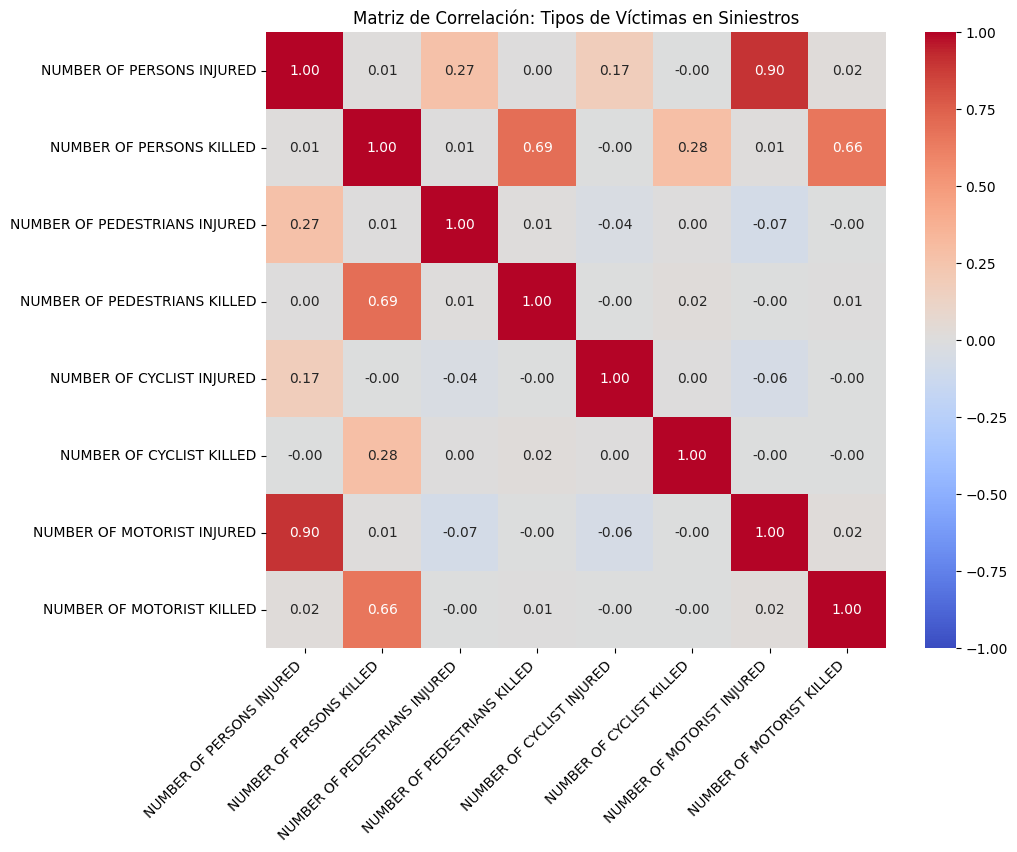

In [19]:
# Identificamos si los distintos tipos de víctimas (peatones, ciclistas, motoristas) están correlacionados en un mismo siniestro o si responden a dinámicas independientes.

corr_data = crashes_numeric.select(*cols_severidad).toPandas()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación: Tipos de Víctimas en Siniestros")
plt.xticks(rotation=45, ha='right')
plt.savefig("graphs/corr_victimas.png", dpi=150, bbox_inches="tight")
plt.show()

,Tipo de usuario,% de choques
0,Peatones,5.83
1,Ciclistas,2.94
2,Motoristas,15.59


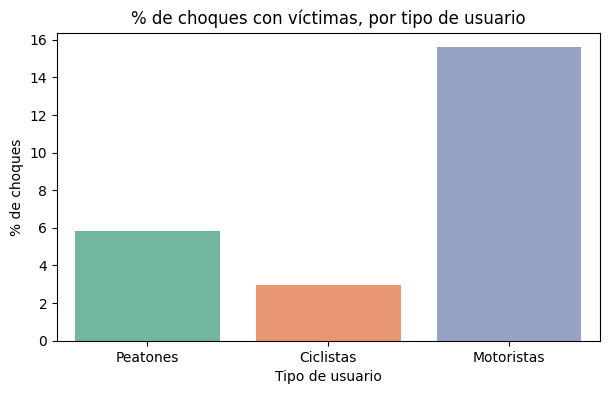

,n_tipos,count
0,0,1616121
1,1,512802
2,2,3269
3,3,26


In [20]:
# Víctimas por tipo de usuario

def tiene(h, m):
    return F.when((F.col(h) > 0) | (F.col(m) > 0), 1).otherwise(0)

tipos_df = crashes_numeric.select(
    tiene("NUMBER OF PEDESTRIANS INJURED", "NUMBER OF PEDESTRIANS KILLED").alias("Peatones"),
    tiene("NUMBER OF CYCLIST INJURED", "NUMBER OF CYCLIST KILLED").alias("Ciclistas"),
    tiene("NUMBER OF MOTORIST INJURED", "NUMBER OF MOTORIST KILLED").alias("Motoristas"))

# % de TODOS los choques con víctimas (heridos o muertos) de cada tipo de usuario
pct = (tipos_df.agg(*[(F.avg(c) * 100).alias(c) for c in tipos_df.columns]).toPandas().T
       .reset_index().rename(columns={"index": "Tipo de usuario", 0: "% de choques"}))
display(pct.round(2))

plt.figure(figsize=(7, 4))
sns.barplot(data=pct, x="Tipo de usuario", y="% de choques", hue="Tipo de usuario", palette="Set2", legend=False)
plt.title("% de choques con víctimas, por tipo de usuario")
plt.savefig("graphs/victimas_tipo_usuario.png", dpi=150, bbox_inches="tight"); plt.show()

# ¿Cuántos tipos de usuario resultan afectados en un mismo choque?
multi = (tipos_df.withColumn("n_tipos", F.col("Peatones") + F.col("Ciclistas") + F.col("Motoristas"))
         .groupBy("n_tipos").count().orderBy("n_tipos").toPandas())
display(multi)

,condicion,horas,choques,choques_por_hora,pct_con_victimas
2,Nieve,2097,45604,21.75,19.08
3,Lluvia,15100,303765,20.12,25.74
1,Nublado,49680,936226,18.85,23.97
0,Despejado,47075,846623,17.98,25.34


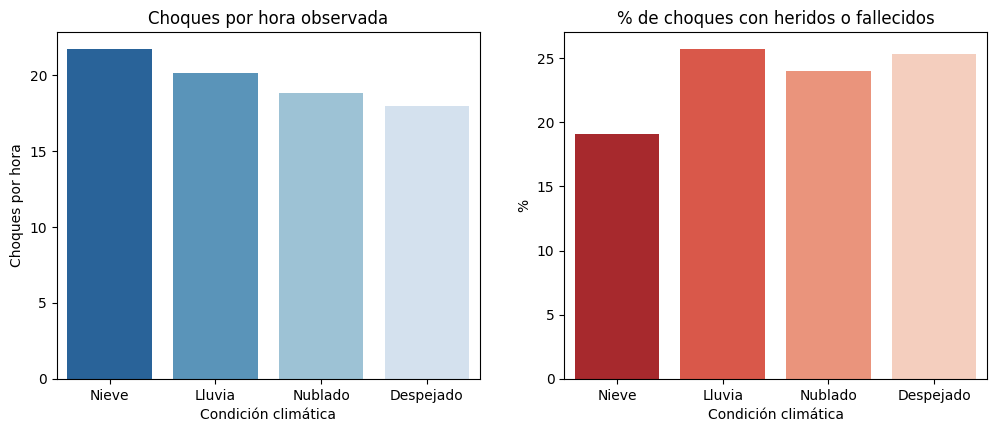

In [21]:
# Choques por hora observada y % de choques con víctimas, según condición climática (2013-2025)
hours_cond = weather_city.groupBy("condicion").count().withColumnRenamed("count", "horas").toPandas()

crashes_w = (crashes_numeric
    .join(weather_city,
          (crashes_numeric.date_parsed == weather_city.fecha) & (crashes_numeric.hour == weather_city.hora),
          "inner")
    .withColumn("con_victimas", F.when((F.col("NUMBER OF PERSONS INJURED") > 0) |
                                       (F.col("NUMBER OF PERSONS KILLED") > 0), 1).otherwise(0)))

crashes_cond = (crashes_w.groupBy("condicion")
    .agg(F.count("*").alias("choques"), F.avg("con_victimas").alias("prop_victimas"))
    .toPandas())

tabla_clima = pd.merge(crashes_cond, hours_cond, on="condicion")
tabla_clima["choques_por_hora"] = tabla_clima["choques"] / tabla_clima["horas"]
tabla_clima["pct_con_victimas"] = tabla_clima["prop_victimas"] * 100
tabla_clima = tabla_clima.sort_values("choques_por_hora", ascending=False)
display(tabla_clima[["condicion", "horas", "choques", "choques_por_hora", "pct_con_victimas"]].round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=tabla_clima, x="condicion", y="choques_por_hora", hue="condicion", palette="Blues_r", legend=False, ax=ax[0])
ax[0].set_title("Choques por hora observada"); ax[0].set_xlabel("Condición climática"); ax[0].set_ylabel("Choques por hora")
sns.barplot(data=tabla_clima, x="condicion", y="pct_con_victimas", hue="condicion", palette="Reds_r", legend=False, ax=ax[1])
ax[1].set_title("% de choques con heridos o fallecidos"); ax[1].set_xlabel("Condición climática"); ax[1].set_ylabel("%")
plt.savefig("graphs/siniestros_clima.png", dpi=150, bbox_inches="tight"); plt.show()

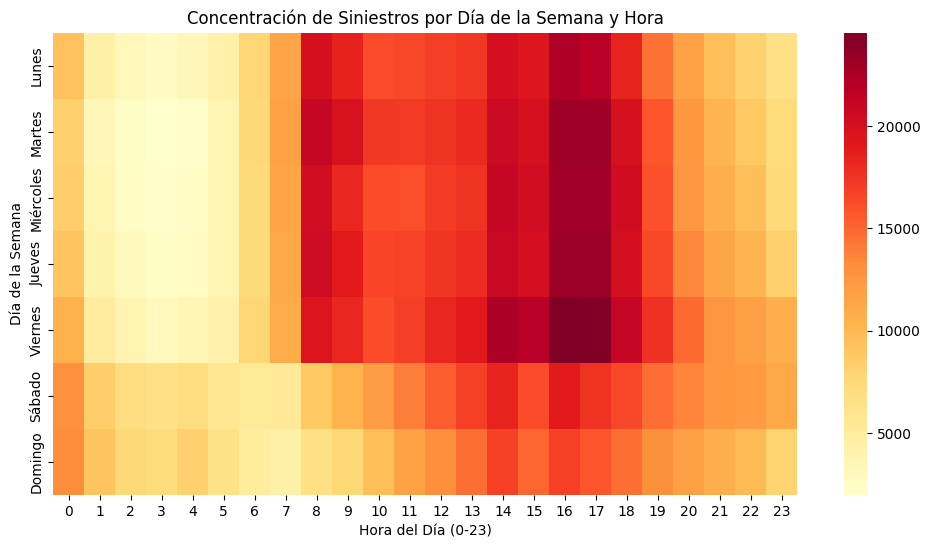

In [22]:
# Siniestros por día de la semana y hora

crashes_hm_df = crashes_time.withColumn("day_of_week", F.date_format("date_parsed", "EEEE"))
crashes_hm = crashes_hm_df.groupBy("day_of_week", "hour").count().toPandas()

dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dias_es = {"Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles", "Thursday": "Jueves",
           "Friday": "Viernes", "Saturday": "Sábado", "Sunday": "Domingo"}

crashes_hm["day_of_week"] = pd.Categorical(crashes_hm["day_of_week"], categories=dias_orden, ordered=True)
pivot_cr = (crashes_hm.pivot_table(index="day_of_week", columns="hour", values="count", observed=False)
            .fillna(0).rename(index=dias_es))

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_cr, cmap="YlOrRd")
plt.title("Concentración de Siniestros por Día de la Semana y Hora")
plt.xlabel("Hora del Día (0-23)")
plt.ylabel("Día de la Semana")
plt.savefig("graphs/crashes_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

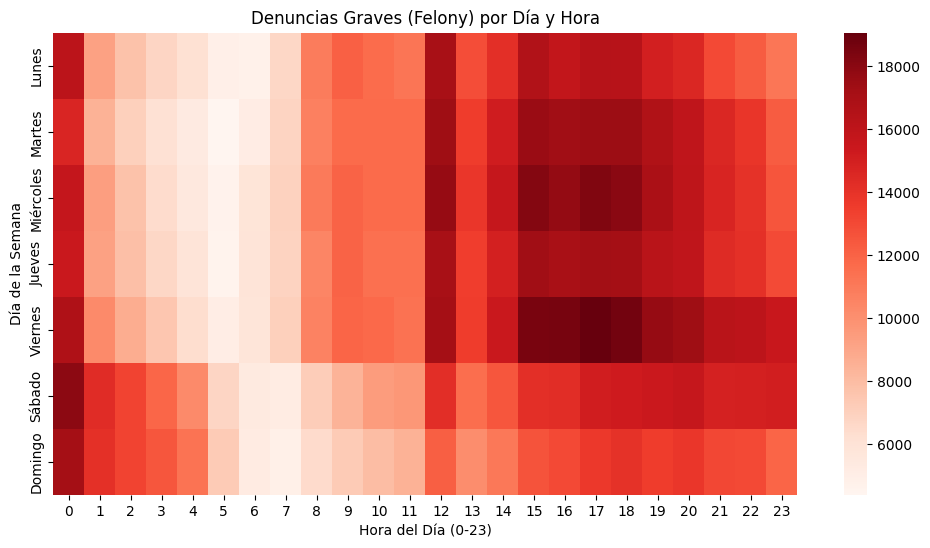

11:00:00: 83,060 denuncias (1.29% de las que tienen hora)


12:00:00: 157,594 denuncias (2.45% de las que tienen hora)


13:00:00: 96,956 denuncias (1.51% de las que tienen hora)


00:00:00: 63,511 denuncias (0.99% de las que tienen hora)


[Stage 145:===================================================>   (29 + 2) / 31]

01:00:00: 59,817 denuncias (0.93% de las que tienen hora)


In [23]:
# Denuncias graves por franja horaria y día
felonies = complaints_time.filter(F.col("LAW_CAT_CD") == "FELONY") \
    .filter(F.col("CMPLNT_FR_TM").isNotNull()) \
    .withColumn("hour", F.substring("CMPLNT_FR_TM", 1, 2).cast("int")) \
    .withColumn("day_of_week", F.date_format("date_parsed", "EEEE"))
    
fel_hm = felonies.groupBy("day_of_week", "hour").count().toPandas()
fel_hm["day_of_week"] = pd.Categorical(fel_hm["day_of_week"], categories=dias_orden, ordered=True)
pivot_fel = (fel_hm.pivot_table(index="day_of_week", columns="hour", values="count", observed=False)
             .fillna(0).rename(index=dias_es))

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_fel, cmap="Reds")
plt.title("Denuncias Graves (Felony) por Día y Hora")
plt.xlabel("Hora del Día (0-23)")
plt.ylabel("Día de la Semana")
plt.savefig("graphs/felony_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

con_hora = complaints_time.filter(F.col("CMPLNT_FR_TM").isNotNull()).count()
for hh in ["11:00:00", "12:00:00", "13:00:00", "00:00:00", "01:00:00"]:
    n_hh = complaints_time.filter(F.col("CMPLNT_FR_TM") == hh).count()
    print(f"{hh}: {n_hh:,} denuncias ({n_hh / con_hora * 100:.2f}% de las que tienen hora)")

,day,Arrestos,Denuncias,razon_arrestos_denuncias
5,Lunes,398434,886061,0.450
1,Martes,541972,920580,0.589
0,Miércoles,601851,947850,0.635
3,Jueves,571922,927883,0.616
2,Viernes,520443,975755,0.533
4,Sábado,446314,916989,0.487
6,Domingo,354571,854094,0.415


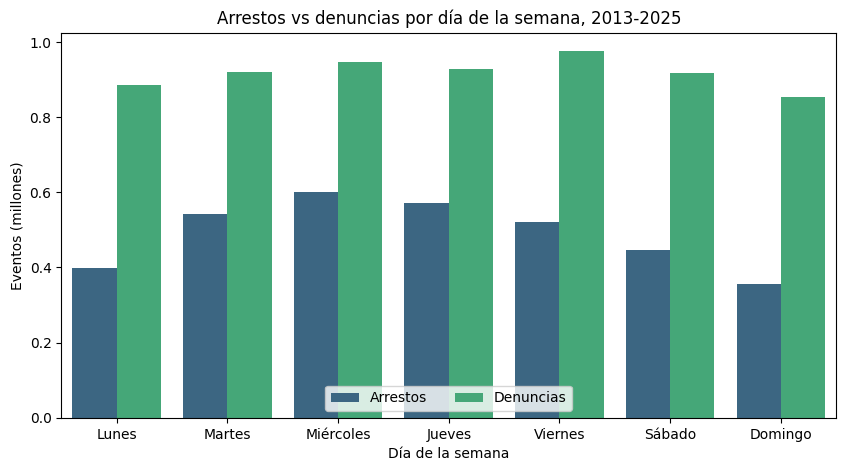

In [24]:
# Arrestos vs denuncias por día de la semana
# Analizamos el desfase temporal entre la actuación policial y la demanda ciudadana

arr_day = (arrests_time.withColumn("day", F.date_format("date_parsed", "EEEE"))
           .groupBy("day").count().withColumnRenamed("count", "Arrestos").toPandas())
comp_day = (complaints_time.withColumn("day", F.date_format("date_parsed", "EEEE"))
            .groupBy("day").count().withColumnRenamed("count", "Denuncias").toPandas())

tabla_dia = pd.merge(arr_day, comp_day, on="day")
tabla_dia["day"] = pd.Categorical(tabla_dia["day"], categories=dias_orden, ordered=True)
tabla_dia = tabla_dia.sort_values("day")
tabla_dia["razon_arrestos_denuncias"] = tabla_dia["Arrestos"] / tabla_dia["Denuncias"]
tabla_dia["day"] = tabla_dia["day"].astype(str).map(dias_es)
display(tabla_dia.round(3))

plot_df = tabla_dia.melt(id_vars="day", value_vars=["Arrestos", "Denuncias"], var_name="Métrica", value_name="Total")
plot_df["Total"] = plot_df["Total"] / 1e6
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="day", y="Total", hue="Métrica", palette="viridis", order=list(dias_es.values()))
plt.title("Arrestos vs denuncias por día de la semana, 2013-2025")
plt.ylabel("Eventos (millones)"); plt.xlabel("Día de la semana")
plt.legend(loc="lower center", ncol=2)
plt.savefig("graphs/arrests_vs_complaints_day.png", dpi=150, bbox_inches="tight"); plt.show()

,borough,Arrestos,Denuncias,razon_arrestos_denuncias
0,QUEENS,693736,1338710,0.518
1,BROOKLYN,949189,1854564,0.512
2,BRONX,768730,1397131,0.550
3,MANHATTAN,888997,1551510,0.573
4,STATEN ISLAND,134855,282208,0.478


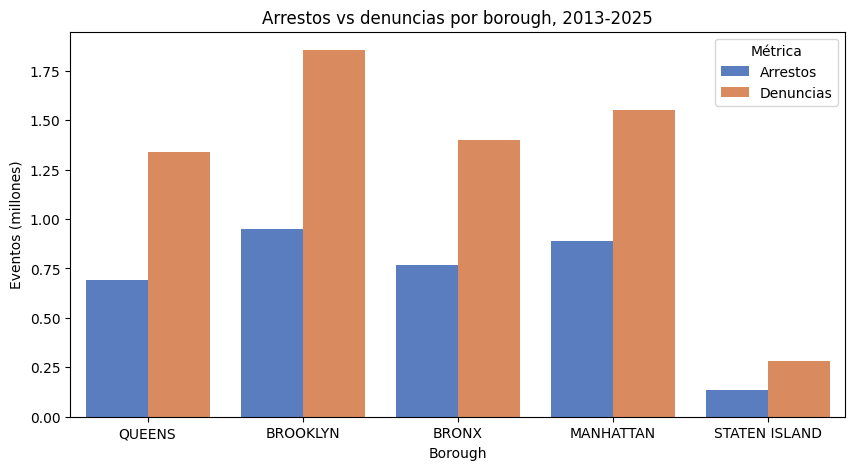

In [25]:
# Comparación de arrestos y denuncias policial por borough

cinco = list(mapa_boro.values())
arr_b = (arrests_time.filter(F.col("borough").isin(cinco)).groupBy("borough").count()
         .withColumnRenamed("count", "Arrestos").toPandas())
comp_b = (complaints_time.filter(F.col("borough").isin(cinco)).groupBy("borough").count()
          .withColumnRenamed("count", "Denuncias").toPandas())

tabla_b = pd.merge(arr_b, comp_b, on="borough")
tabla_b["razon_arrestos_denuncias"] = tabla_b["Arrestos"] / tabla_b["Denuncias"]
display(tabla_b.round(3))

plot_b = tabla_b.melt(id_vars="borough", value_vars=["Arrestos", "Denuncias"], var_name="Métrica", value_name="Total")
plot_b["Total"] = plot_b["Total"] / 1e6
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_b, x="borough", y="Total", hue="Métrica", palette="muted")
plt.title("Arrestos vs denuncias por borough, 2013-2025")
plt.ylabel("Eventos (millones)"); plt.xlabel("Borough")
plt.savefig("graphs/arrests_vs_complaints_boro.png", dpi=150, bbox_inches="tight"); plt.show()

[Stage 163:>                                                        (0 + 1) / 1]

Choques sin borough (excluidos): 659,713 (30.9%)


,Borough,Choques,Población,tasa_100k_acum,tasa_100k_anual
3,Manhattan,322466,1638025,19686.0,1514.0
1,Brooklyn,473801,2655570,17842.0,1372.0
0,Queens,396201,2342047,16917.0,1301.0
2,Bronx,220044,1423729,15455.0,1189.0
4,Staten Island,59993,494308,12137.0,934.0


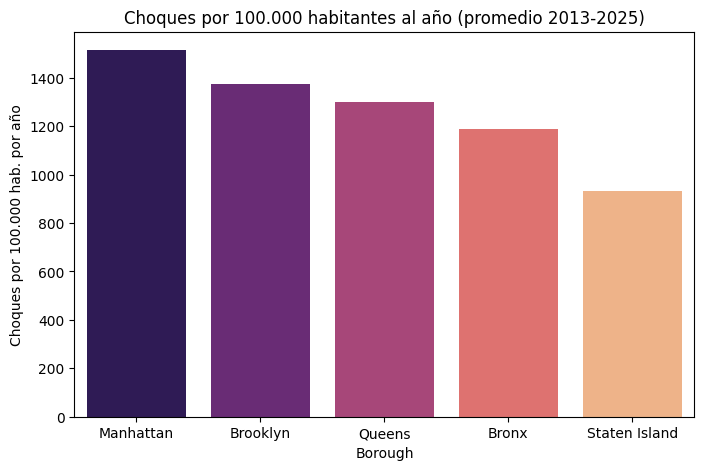

,anio,pct_sin_borough
0,2013,23.4
1,2014,24.1
2,2015,24.9
3,2016,33.3
4,2017,38.1
5,2018,35.6
6,2019,35.2
7,2020,34.7
8,2021,34.7
9,2022,33.8


In [26]:
# Tasa de siniestros por población
# Aqui normalizamos con web scraping 
# la normalización se aplcia cruzando lso conteos absolutos con los datos poblaciones obtenidos por OCR
# Agrupar directamente por BOROUGH sin filtrar nulos o vacíos
crashes_boro = (crashes_time.filter(F.col("borough").isin(list(mapa_boro.values())))
                .groupBy("borough").count().toPandas())

crashes_boro["Borough_match"] = crashes_boro["borough"]

pop_df["Borough_match"] = pop_df["Borough"].str.strip().str.upper()

merged_pop = pd.merge(crashes_boro, pop_df, on="Borough_match", how="inner")
merged_pop["tasa_100k_acum"] = merged_pop["count"] / merged_pop["Total"] * 100000
merged_pop["tasa_100k_anual"] = merged_pop["tasa_100k_acum"] / 13   # 2013-2025 son 13 años
merged_pop = merged_pop.sort_values("tasa_100k_acum", ascending=False)

total_choques = crashes_time.count()

con_borough = int(merged_pop["count"].sum())

print(f"Choques sin borough (excluidos): {total_choques - con_borough:,} "
      f"({(total_choques - con_borough) / total_choques * 100:.1f}%)")

display(merged_pop[["Borough", "count", "Total", "tasa_100k_acum", "tasa_100k_anual"]]
        .rename(columns={"count": "Choques", "Total": "Población"}).round(0))

plt.figure(figsize=(8, 5))
sns.barplot(data=merged_pop, x="Borough", y="tasa_100k_anual", hue="Borough", palette="magma", legend=False)
plt.title("Choques por 100.000 habitantes al año (promedio 2013-2025)")
plt.ylabel("Choques por 100.000 hab. por año"); plt.xlabel("Borough")
plt.savefig("graphs/tasa_siniestros.png", dpi=150, bbox_inches="tight"); plt.show()

# ¿El borough faltante se concentra en ciertos años? (sesgo de las tasas)
faltante_anio = (crashes_time.withColumn("anio", F.year("date_parsed"))
    .groupBy("anio")
    .agg((F.avg(F.when(F.col("borough").isNull(), 1).otherwise(0)) * 100).alias("pct_sin_borough"))
    .orderBy("anio").toPandas())
display(faltante_anio.round(1))

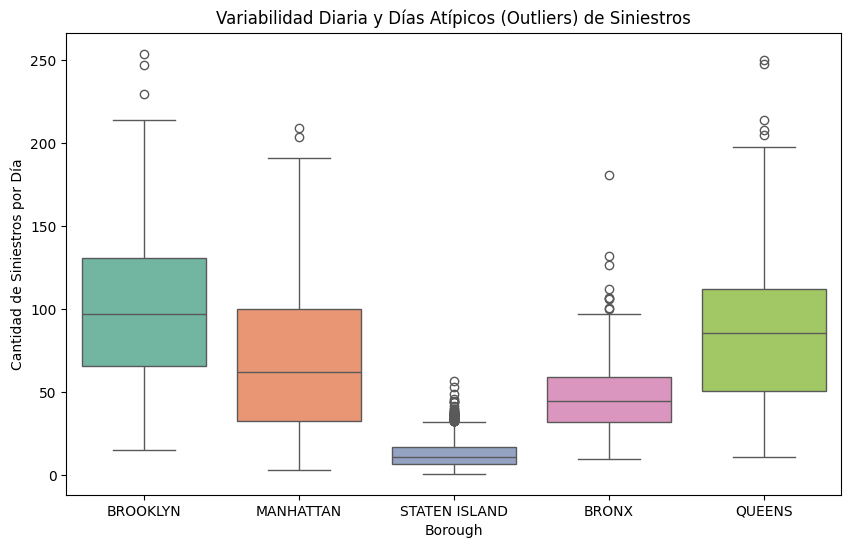

,BOROUGH,date_parsed,count
19503,BROOKLYN,2014-01-21,254
22135,QUEENS,2014-02-03,250
8469,QUEENS,2014-01-21,248
4600,BROOKLYN,2015-02-03,247
8997,BROOKLYN,2014-02-03,230
8109,BROOKLYN,2015-03-05,214
11184,QUEENS,2018-11-15,214
17070,BROOKLYN,2018-11-15,214
21804,MANHATTAN,2015-03-06,209
12692,QUEENS,2015-03-05,208


In [27]:
# Distribución diaria de crashes por borough (Boxplot)
crashes_daily = crashes_time.filter(F.length(F.col("BOROUGH")) > 1) \
    .groupBy("BOROUGH", "date_parsed").count().toPandas()
    
plt.figure(figsize=(10, 6))
sns.boxplot(data=crashes_daily, x="BOROUGH", y="count", hue="BOROUGH", palette="Set2", legend=False)
plt.title("Variabilidad Diaria y Días Atípicos (Outliers) de Siniestros")
plt.ylabel("Cantidad de Siniestros por Día")
plt.xlabel("Borough")
plt.savefig("graphs/outliers_crashes.png", dpi=150, bbox_inches="tight")
plt.show()

display(crashes_daily.sort_values("count", ascending=False).head(10))

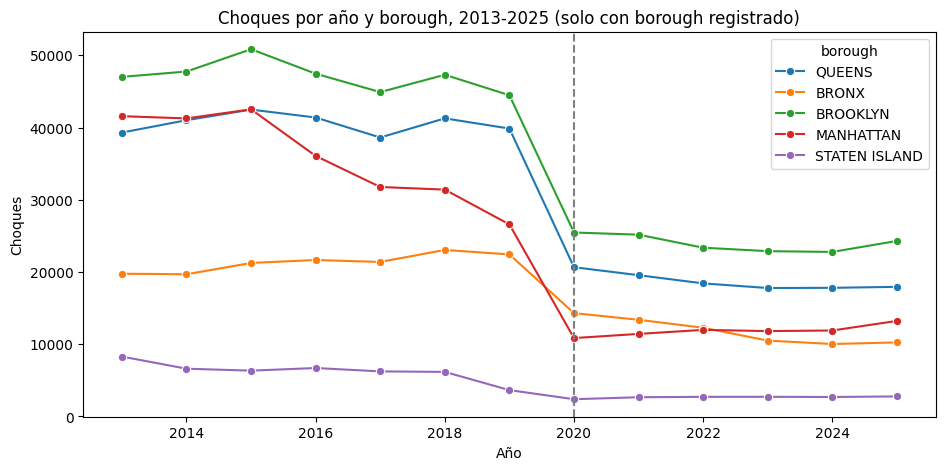

borough,BRONX,BROOKLYN,MANHATTAN,QUEENS,STATEN ISLAND
anio,,,,,
2013,19768,47024,41582,39312,8295
2014,19688,47761,41270,41023,6614
2015,21258,50851,42528,42493,6344
2016,21660,47464,36077,41396,6709
2017,21397,44915,31774,38627,6241
2018,23060,47313,31412,41278,6171
2019,22437,44479,26593,39865,3650
2020,14306,25473,10855,20667,2388
2021,13389,25174,11432,19564,2665


In [28]:
# Choques por año y borough
crashes_anual = (crashes_time.filter(F.col("borough").isin(list(mapa_boro.values())))
                 .groupBy(F.year("date_parsed").alias("anio"), "borough").count().toPandas())
plt.figure(figsize=(11, 5))
sns.lineplot(data=crashes_anual, x="anio", y="count", hue="borough", marker="o")
plt.axvline(2020, color="gray", linestyle="--")
plt.title("Choques por año y borough, 2013-2025 (solo con borough registrado)")
plt.ylabel("Choques"); plt.xlabel("Año")
plt.savefig("graphs/choques_anuales.png", dpi=150, bbox_inches="tight"); plt.show()

display(crashes_anual.pivot(index="anio", columns="borough", values="count"))


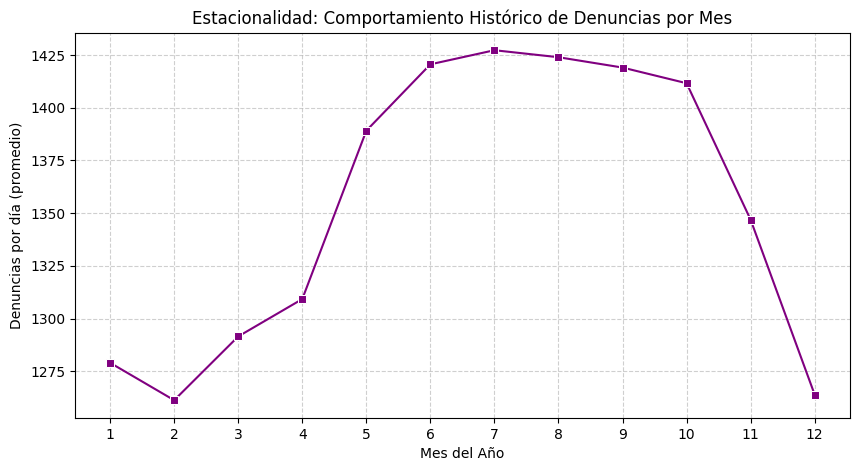

,MONTH,count
0,1,1279.0
1,2,1261.0
2,3,1292.0
3,4,1309.0
4,5,1389.0
5,6,1421.0
6,7,1427.0
7,8,1424.0
8,9,1419.0
9,10,1412.0


In [29]:
# Analizamos la tendencia de las denuncias 
diario = complaints_time.groupBy("date_parsed").count()
complaints_month = (diario.groupBy(F.month("date_parsed").alias("MONTH"))
                    .agg(F.avg("count").alias("count")).orderBy("MONTH").toPandas())
  
plt.figure(figsize=(10, 5))
sns.lineplot(data=complaints_month, x="MONTH", y="count", marker="s", color="purple")
plt.title("Estacionalidad: Comportamiento Histórico de Denuncias por Mes")
plt.xlabel("Mes del Año")
plt.ylabel("Denuncias por día (promedio)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("graphs/estacionalidad_mes.png", dpi=150, bbox_inches="tight")
plt.show()

display(complaints_month.round(0))

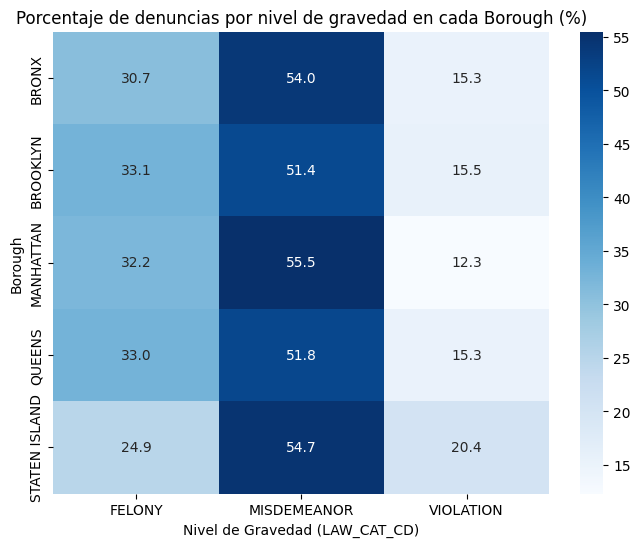

In [30]:
# Quejas por gravedad del delito
# Agrupamos las denuncias según si son delitos graves (Felony), menores (Misdemeanor) o violaciones.
complaints_boro_type = (complaints_time
    .filter(F.col("borough").isin(list(mapa_boro.values())) &
            F.col("LAW_CAT_CD").isin("FELONY", "MISDEMEANOR", "VIOLATION"))
    .groupBy("borough", "LAW_CAT_CD").count().toPandas())

pivot_complaints = complaints_boro_type.pivot(index="borough", columns="LAW_CAT_CD", values="count").fillna(0)
pivot_complaints_pct = pivot_complaints.div(pivot_complaints.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_complaints_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Porcentaje de denuncias por nivel de gravedad en cada Borough (%)")
plt.ylabel("Borough")
plt.xlabel("Nivel de Gravedad (LAW_CAT_CD)")
plt.savefig("graphs/denuncias_gravedad_borough.png", dpi=150, bbox_inches="tight")
plt.show()


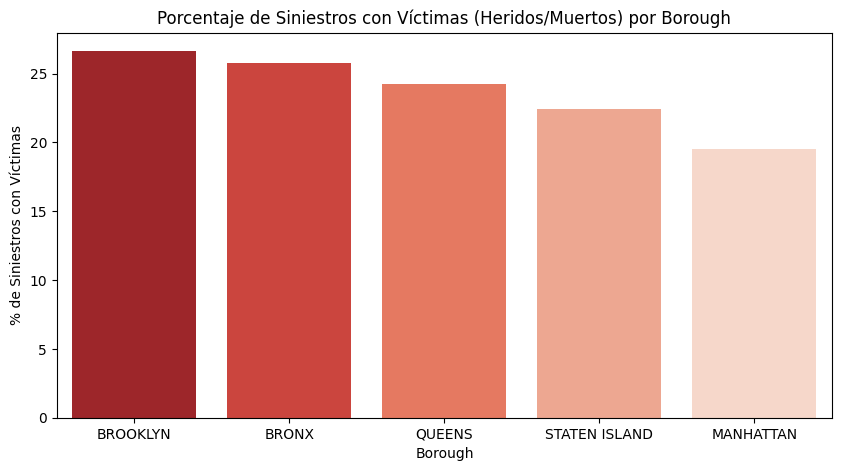

,BOROUGH,total_crashes,crashes_with_victims,pct_victims
1,BROOKLYN,473801,126211,26.64
2,BRONX,220044,56770,25.80
0,QUEENS,396201,96190,24.28
4,STATEN ISLAND,59993,13469,22.45
3,MANHATTAN,322466,62942,19.52


In [31]:
# Proporción de siniestros con víctimas (heridos/muertos) por Borough
crashes_sev = crashes_numeric.dropna(subset=["BOROUGH"])
crashes_sev = crashes_sev.withColumn("has_victim", F.when((F.col("NUMBER OF PERSONS INJURED") > 0) | (F.col("NUMBER OF PERSONS KILLED") > 0), 1).otherwise(0))

severity_boro = crashes_sev.groupBy("BOROUGH").agg(
    F.count("*").alias("total_crashes"),
    F.sum("has_victim").alias("crashes_with_victims")
).toPandas()

severity_boro["pct_victims"] = (severity_boro["crashes_with_victims"] / severity_boro["total_crashes"]) * 100
severity_boro = severity_boro.sort_values("pct_victims", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=severity_boro, x="BOROUGH", y="pct_victims",hue="BOROUGH", palette="Reds_r", legend=False)
plt.title("Porcentaje de Siniestros con Víctimas (Heridos/Muertos) por Borough")
plt.ylabel("% de Siniestros con Víctimas")
plt.xlabel("Borough")
plt.savefig("graphs/pct_victimas_borough.png", dpi=150, bbox_inches="tight")
plt.show()

display(severity_boro[["BOROUGH", "total_crashes", "crashes_with_victims", "pct_victims"]].round(2))

,franja,tipo_dia,choques,pct_con_victimas
1,00-06,Entre semana,126219,27.21
3,06-12,Entre semana,456151,21.74
6,12-18,Entre semana,615176,23.34
2,18-24,Entre semana,388747,28.30
5,00-06,Fin de semana,99872,27.46
4,06-12,Fin de semana,101243,22.37
0,12-18,Fin de semana,195810,23.55
7,18-24,Fin de semana,149000,28.52


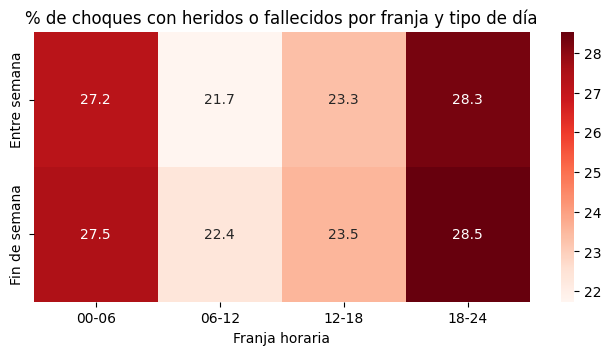

In [32]:
# Gravedad de los choques según franja horaria y tipo de día
sev = (crashes_numeric
    .filter(F.col("franja").isNotNull())
    .withColumn("tipo_dia", F.when(F.dayofweek("date_parsed").isin(1, 7), "Fin de semana").otherwise("Entre semana"))
    .withColumn("con_victimas", F.when((F.col("NUMBER OF PERSONS INJURED") > 0) |
                                       (F.col("NUMBER OF PERSONS KILLED") > 0), 1).otherwise(0))
    .groupBy("franja", "tipo_dia")
    .agg(F.count("*").alias("choques"), (F.avg("con_victimas") * 100).alias("pct_con_victimas"))
    .toPandas())
display(sev.sort_values(["tipo_dia", "franja"]).round(2))

pivot_sev = sev.pivot(index="tipo_dia", columns="franja", values="pct_con_victimas")
plt.figure(figsize=(8, 3.5))
sns.heatmap(pivot_sev, annot=True, fmt=".1f", cmap="Reds")
plt.title("% de choques con heridos o fallecidos por franja y tipo de día")
plt.ylabel(""); plt.xlabel("Franja horaria")
plt.savefig("graphs/pct_victimas_franja.png", dpi=150, bbox_inches="tight"); plt.show()

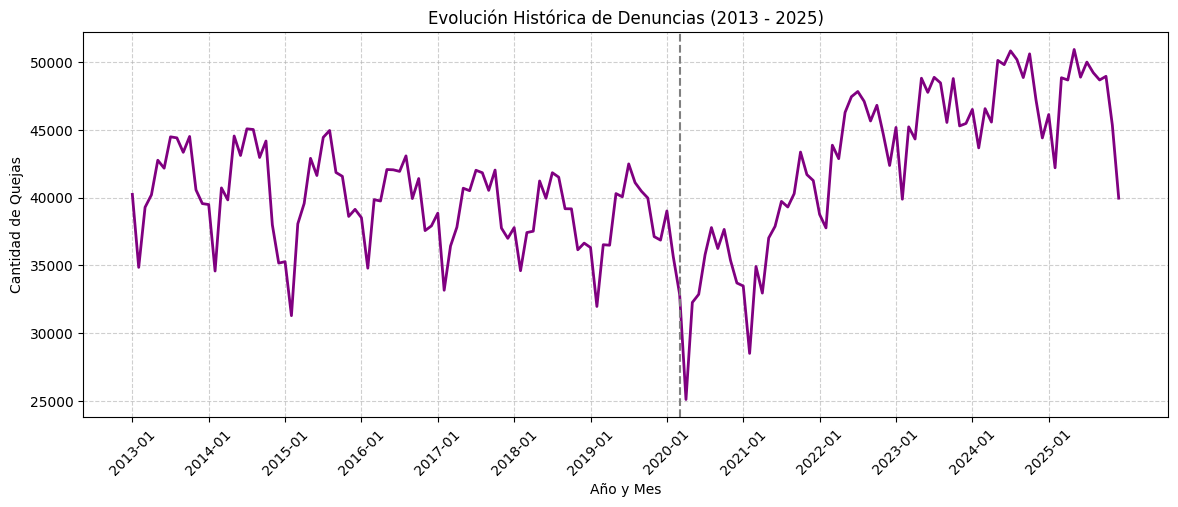

,year_month,count
136,2020-04,25109
47,2021-02,28508
147,2015-02,31290


,year_month,count
138,2025-05,50914
109,2024-07,50810
102,2024-10,50591


In [33]:
# Serie temporal de largo plazo (Evolución de quejas)

complaints_trend = (complaints_time
    .withColumn("year_month", F.date_format("date_parsed", "yyyy-MM"))
    .groupBy("year_month").count().toPandas())
    
complaints_trend = complaints_trend.sort_values("year_month")

plt.figure(figsize=(14, 5))
plt.plot(complaints_trend["year_month"], complaints_trend["count"], marker='', color='purple', linewidth=2)
plt.title("Evolución Histórica de Denuncias (2013 - 2025)")
plt.xlabel("Año y Mes")
plt.ylabel("Cantidad de Quejas")
plt.xticks(complaints_trend["year_month"][::12], rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.axvline("2020-03", color="gray", linestyle="--")   # inicio de la pandemia
plt.savefig("graphs/denuncias_tendencia.png", dpi=150, bbox_inches="tight")
plt.show()

display(complaints_trend.nsmallest(3, "count"))   # meses con menos denuncias
display(complaints_trend.nlargest(3, "count"))    # meses con más denuncias

+---------------+-----+
|NYCgov_Pov_Stat|count|
+---------------+-----+
|              1|12113|
|              2|56160|
+---------------+-----+

Tasa de toda la ciudad (%): 19.3


,Borough_Name,Tasa_Pobreza
0,Bronx,27.12
1,Brooklyn,20.31
3,Queens,17.02
4,Staten Island,16.00
2,Manhattan,15.12


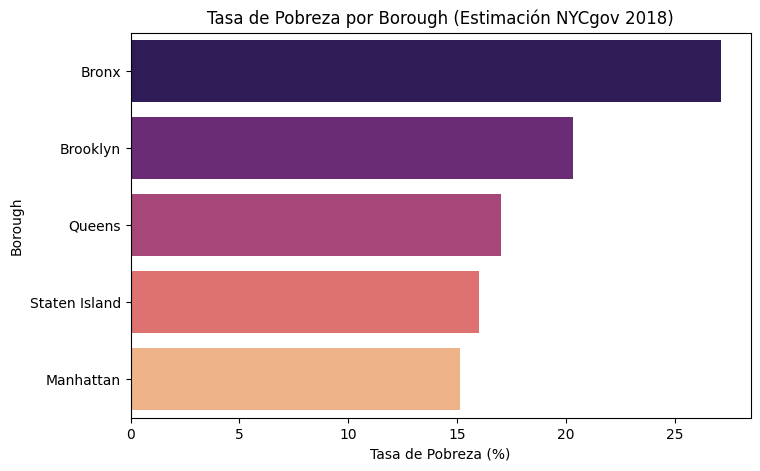

In [34]:
# Tasa de pobreza por borough
# Miramos si las zonas de mayor urgencia/riesgo coinciden con vulnerabilidad socioeconómica

poverty_raw.groupBy("NYCgov_Pov_Stat").count().show()   # 1 = en pobreza, 2 = no 
pov_df = poverty_raw.select("Boro", "NYCgov_Pov_Stat", "PWGTP").toPandas()

boro_names = {1: 'Bronx', 2: 'Brooklyn', 3: 'Manhattan', 4: 'Queens', 5: 'Staten Island'}
pov_df['Borough_Name'] = pov_df['Boro'].map(boro_names)

pov_df['is_poor'] = (pov_df['NYCgov_Pov_Stat'] == 1).astype(int)
pov_df['weighted_poor'] = pov_df['is_poor'] * pov_df['PWGTP']

# Verificación: la ciudad publicó 19,1 % para 2018
print("Tasa de toda la ciudad (%):", round(pov_df["weighted_poor"].sum() / pov_df["PWGTP"].sum() * 100, 1))

g = pov_df.groupby('Borough_Name')[['weighted_poor', 'PWGTP']].sum()
poverty_rates = ((g['weighted_poor'] / g['PWGTP'] * 100)
                 .reset_index(name='Tasa_Pobreza')
                 .sort_values("Tasa_Pobreza", ascending=False))

display(poverty_rates.round(2))
plt.figure(figsize=(8, 5))
sns.barplot(data=poverty_rates, x="Tasa_Pobreza", y="Borough_Name", hue="Borough_Name", palette="magma", legend=False)
plt.title("Tasa de Pobreza por Borough (Estimación NYCgov 2018)")
plt.xlabel("Tasa de Pobreza (%)")
plt.ylabel("Borough")
plt.savefig("graphs/pobreza_borough.png", dpi=150, bbox_inches="tight")
plt.show()

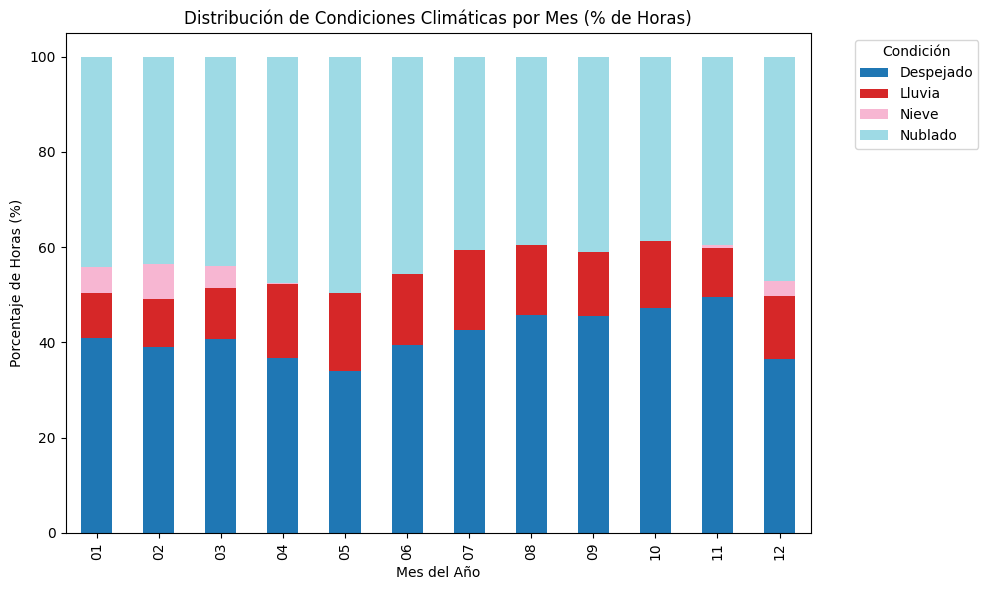

In [35]:
# Estacionalidad de las condiciones climáticas
# Miramos en qué meses llueve o nieva más con el fin de identificar si ayuda a predecir si el componente 
# climático del riesgo es estacional
weather_df = weather_raw.filter(F.col("anio") <= 2025).select("mes", "condicion").toPandas()
weather_df["mes_num"] = weather_df["mes"].str[-2:]

clima_pivot = weather_df.groupby(["mes_num", "condicion"]).size().unstack(fill_value=0)
clima_pct = clima_pivot.div(clima_pivot.sum(axis=1), axis=0) * 100

clima_pct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Distribución de Condiciones Climáticas por Mes (% de Horas)")
plt.xlabel("Mes del Año")
plt.ylabel("Porcentaje de Horas (%)")
plt.legend(title="Condición", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


,Borough,Denuncias graves,Población,tasa_100k_acum,tasa_100k_anual
3,Manhattan,499421,1638025,30489.0,2345.0
2,Bronx,428982,1423729,30131.0,2318.0
1,Brooklyn,612975,2655570,23083.0,1776.0
0,Queens,441146,2342047,18836.0,1449.0
4,Staten Island,70289,494308,14220.0,1094.0


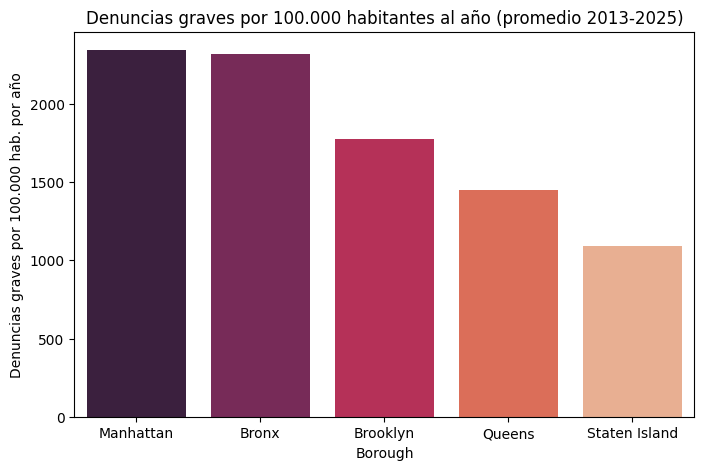

In [36]:
# Denuncias graves por 100.000 habitantes y borough (promedio anual 2013-2025)
pop_df["Borough_match"] = pop_df["Borough"].str.strip().str.upper()

fel_boro = (complaints_time
    .filter((F.col("LAW_CAT_CD") == "FELONY") & F.col("borough").isin(list(mapa_boro.values())))
    .groupBy("borough").count().toPandas())
fel_boro["Borough_match"] = fel_boro["borough"]

fel = pd.merge(fel_boro, pop_df, on="Borough_match", how="inner")
fel["tasa_100k_acum"] = fel["count"] / fel["Total"] * 100000
fel["tasa_100k_anual"] = fel["tasa_100k_acum"] / 13
fel = fel.sort_values("tasa_100k_acum", ascending=False)

display(fel[["Borough", "count", "Total", "tasa_100k_acum", "tasa_100k_anual"]]
        .rename(columns={"count": "Denuncias graves", "Total": "Población"}).round(0))

plt.figure(figsize=(8, 5))
sns.barplot(data=fel, x="Borough", y="tasa_100k_anual", hue="Borough", palette="rocket", legend=False)
plt.title("Denuncias graves por 100.000 habitantes al año (promedio 2013-2025)")
plt.ylabel("Denuncias graves por 100.000 hab. por año"); plt.xlabel("Borough")
plt.savefig("graphs/felony_tasa.png", dpi=150, bbox_inches="tight"); plt.show()

In [37]:
#
tot_fel = complaints_time.filter(F.col("LAW_CAT_CD") == "FELONY").count()
top_fel = (complaints_time.filter(F.col("LAW_CAT_CD") == "FELONY")
    .groupBy("OFNS_DESC").count().orderBy(F.desc("count")).limit(10).toPandas())
top_fel["% de las denuncias graves"] = top_fel["count"] / tot_fel * 100
display(top_fel.round(2))

,OFNS_DESC,count,% de las denuncias graves
0,GRAND LARCENY,582007,28.35
1,FELONY ASSAULT,300434,14.63
2,ROBBERY,201583,9.82
3,MISCELLANEOUS PENAL LAW,185857,9.05
4,BURGLARY,181076,8.82
5,CRIMINAL MISCHIEF & RELATED OF,151771,7.39
6,GRAND LARCENY OF MOTOR VEHICLE,121775,5.93
7,DANGEROUS DRUGS,69709,3.40
8,FORGERY,67264,3.28
9,DANGEROUS WEAPONS,62738,3.06


,franja,condicion,choques,pct_victimas,horas,choques_por_hora
2,00-06,Despejado,99137,27.14,12880,7.70
7,00-06,Lluvia,30667,27.57,3418,8.97
9,00-06,Nieve,4689,22.24,506,9.27
13,00-06,Nublado,91598,27.69,11684,7.84
3,06-12,Despejado,237004,22.83,12037,19.69
1,06-12,Lluvia,74147,22.35,3675,20.18
5,06-12,Nieve,13744,17.22,569,24.15
6,06-12,Nublado,232499,20.97,12207,19.05
14,12-18,Despejado,284541,24.47,9881,28.80
10,12-18,Lluvia,124409,24.38,4437,28.04


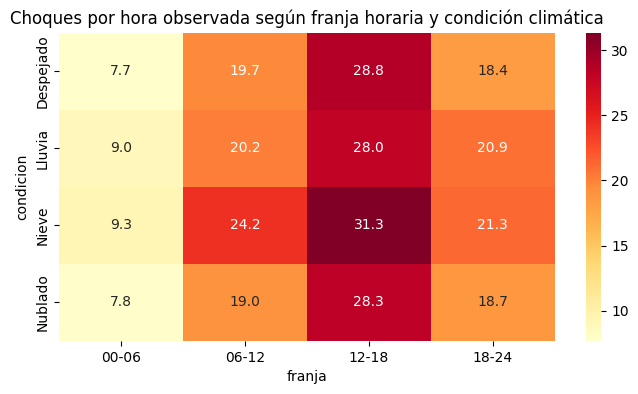

In [38]:
#
horas_fc = (weather_city.withColumn("franja", franja(F.col("hora")))
            .groupBy("franja", "condicion").count().withColumnRenamed("count", "horas").toPandas())

choques_fc = (crashes_w.filter(F.col("franja").isNotNull())
              .groupBy("franja", "condicion")
              .agg(F.count("*").alias("choques"), (F.avg("con_victimas") * 100).alias("pct_victimas"))
              .toPandas())

fc = pd.merge(choques_fc, horas_fc, on=["franja", "condicion"])
fc["choques_por_hora"] = fc["choques"] / fc["horas"]
display(fc.sort_values(["franja", "condicion"]).round(2)) # revisa la columna "horas": si es muy baja, tómalo con cautela  

piv = fc.pivot(index="condicion", columns="franja", values="choques_por_hora")
plt.figure(figsize=(8, 4))
sns.heatmap(piv, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Choques por hora observada según franja horaria y condición climática")
plt.savefig("graphs/clima_por_franja.png", dpi=150, bbox_inches="tight"); plt.show()

In [39]:
#
top_dias = crashes_daily.sort_values("count", ascending=False).head(10).copy()
clima_dia = (weather_raw.filter(F.col("borough") == "Manhattan")
             .groupBy("fecha")
             .agg(F.sum("snowfall").alias("nieve_cm"),
                  F.sum("precipitation").alias("precip_mm"),
                  F.min("temperature_2m").alias("temp_min_c"))
             .toPandas())
clima_dia["fecha"] = pd.to_datetime(clima_dia["fecha"])
top_dias["date_parsed"] = pd.to_datetime(top_dias["date_parsed"])
display(top_dias.merge(clima_dia, left_on="date_parsed", right_on="fecha").drop(columns="fecha").round(1))

,BOROUGH,date_parsed,count,nieve_cm,precip_mm,temp_min_c
0,BROOKLYN,2014-01-21,254,6.2,8.6,-10.7
1,QUEENS,2014-02-03,250,18.7,27.4,-2.9
2,QUEENS,2014-01-21,248,6.2,8.6,-10.7
3,BROOKLYN,2015-02-03,247,0.0,0.0,-15.5
4,BROOKLYN,2014-02-03,230,18.7,27.4,-2.9
5,BROOKLYN,2015-03-05,214,9.5,18.8,-6.9
6,QUEENS,2018-11-15,214,11.3,21.7,-1.5
7,BROOKLYN,2018-11-15,214,11.3,21.7,-1.5
8,MANHATTAN,2015-03-06,209,0.1,0.0,-15.4
9,QUEENS,2015-03-05,208,9.5,18.8,-6.9


## 5. Reporte de calidad de datos
En esta sección se evalúa la calidad de las fuentes utilizadas antes de realizar las transformaciones permitiendo identificar cantidad de valores nulos. Informacion con la cual se decide un tratamiento especficifo a cada atributo.

In [40]:
# Genera un reporte de valores faltantes para cada columna de un dataset.
# Se consideran como faltantes los valores nulos, cadenas vacías y "(null)".
# Para variables numéricas también se consideran los valores NaN.
def missing_report(df, dataset_name):
    total = df.count()
    tipos = dict(df.dtypes)

    def faltante(c):
        cond = F.col(c).isNull() | F.trim(F.col(c).cast("string")).isin("", "(null)")
        if tipos[c] in ("double", "float"):
            cond = cond | F.isnan(F.col(c))
        return cond

    exprs = [F.sum(F.when(faltante(c), 1).otherwise(0)).alias(c) for c in df.columns]
    resultado = df.select(exprs)
    return (resultado.select(
                F.lit(dataset_name).alias("dataset"),
                F.explode(F.array(*[F.struct(F.lit(c).alias("column"), F.col(c).alias("missing"))
                                    for c in df.columns])).alias("x"))
            .select("dataset", "x.column", "x.missing")
            .withColumn("total_rows", F.lit(total))
            .withColumn("missing_percentage", F.round(F.col("missing") / F.col("total_rows") * 100, 2)))

In [41]:
# Se genera el reporte de valores faltantes para cada fuente.
crashes_missing = missing_report(
    crashes_raw,
    "Motor Vehicle Collisions - Crashes"
)

arrests_missing = missing_report(
    arrests_raw,
    "NYPD Arrest Data"
)

complaints_missing = missing_report(
    complaints_raw,
    "NYPD Complaint Data Historic"
)

full_report = (
    crashes_missing
    .unionByName(arrests_missing)
    .unionByName(complaints_missing)
)


In [42]:
# Se muestran únicamente las columnas que presentan valores faltantes,
# ordenadas por dataset y porcentaje de datos faltantes.

(full_report.filter(F.col("missing") > 0)
    .orderBy("dataset", F.desc("missing_percentage"))
    .show(200, truncate=False))

[Stage 240:=====================================================> (30 + 1) / 31]

+----------------------------------+-----------------------------+--------+----------+------------------+
|dataset                           |column                       |missing |total_rows|missing_percentage|
+----------------------------------+-----------------------------+--------+----------+------------------+
|Motor Vehicle Collisions - Crashes|VEHICLE TYPE CODE 5          |2259199 |2269187   |99.56             |
|Motor Vehicle Collisions - Crashes|CONTRIBUTING FACTOR VEHICLE 5|2258873 |2269187   |99.55             |
|Motor Vehicle Collisions - Crashes|VEHICLE TYPE CODE 4          |2232943 |2269187   |98.4              |
|Motor Vehicle Collisions - Crashes|CONTRIBUTING FACTOR VEHICLE 4|2231554 |2269187   |98.34             |
|Motor Vehicle Collisions - Crashes|VEHICLE TYPE CODE 3          |2111354 |2269187   |93.04             |
|Motor Vehicle Collisions - Crashes|CONTRIBUTING FACTOR VEHICLE 3|2104798 |2269187   |92.76             |
|Motor Vehicle Collisions - Crashes|OFF STREET

### 7. Transformacion Datos

A partir de los problemas identificados durante la evaluación de calidad, se aplican las transformaciones necesarias para preparar las fuentes para el análisis.

Las transformaciones incluyen la estandarización de formatos, conversión de tipos de datos y tratamiento de valores faltantes. También se homogeneizan elementos comunes entre las diferentes fuentes, como fechas, boroughs y periodos de análisis.

#### Crashes

In [43]:
# Filtro de Atributos a utilizar

crashes = crashes_raw.select(
    "COLLISION_ID",
    "CRASH DATE",
    "CRASH TIME",
    "BOROUGH",
    "LATITUDE",
    "LONGITUDE",
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "CONTRIBUTING FACTOR VEHICLE 1"
)

In [44]:
# Eliminacion de duplicados con base en ID de colision
crashes = crashes.dropDuplicates(["COLLISION_ID"])

In [45]:
# Se elimina ID de colision
crashes = crashes.select(
    "CRASH DATE",
    "CRASH TIME",
    "BOROUGH",
    "LATITUDE",
    "LONGITUDE",
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "CONTRIBUTING FACTOR VEHICLE 1"
) 

In [46]:
# Unificacion de Tiempo y Hora de Accidente en un unico timestamp
crashes = (
    crashes
    .withColumn(
        "CRASH_DATE",
        F.to_date(F.col("CRASH DATE"), "MM/dd/yyyy")
    )
    .withColumn(
        "CRASH_TIME",
        F.to_timestamp(
            F.concat_ws(
                " ",
                F.date_format(F.col("CRASH_DATE"), "yyyy-MM-dd"),
                F.regexp_extract(
                    F.col("CRASH TIME"),
                    r"(\d{2}:\d{2})",
                    1
                )
            ),
            "yyyy-MM-dd HH:mm"
        )
    )
)

crashes = crashes.drop("CRASH DATE", "CRASH TIME","CRASH_DATE")

In [47]:
# Casteo y transformacion de nulos a 0
severity_columns = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
]

for col in severity_columns:
    crashes = crashes.withColumn(
        col,
        F.col(col).cast("integer")
    )

for col in severity_columns:
    crashes = crashes.fillna({col: 0})

In [48]:
# Transformacion de nulos a Unknown
crashes = crashes.withColumn(
    "CONTRIBUTING FACTOR VEHICLE 1",
    F.when(
        F.col("CONTRIBUTING FACTOR VEHICLE 1").isNull() |
        (F.trim(F.col("CONTRIBUTING FACTOR VEHICLE 1")) == ""),
        "UNKNOWN"
    ).otherwise(
        F.upper(F.trim(F.col("CONTRIBUTING FACTOR VEHICLE 1")))
    )
)

In [49]:
# Filtrar tuplas no recuperables por ubicacion
crashes = crashes.filter(
    F.col("BOROUGH").isNotNull()
    |
    (
        F.col("LATITUDE").isNotNull()
        & F.col("LONGITUDE").isNotNull()
    )
)

In [50]:
# Casteo y transformacion de coordenadas a formato decimal
crashes = (
    crashes
    .withColumn(
        "LATITUDE",
        F.regexp_replace(
            F.trim(F.col("LATITUDE")),
            ",",
            "."
        ).cast("double")
    )
    .withColumn(
        "LONGITUDE",
        F.regexp_replace(
            F.trim(F.col("LONGITUDE")),
            ",",
            "."
        ).cast("double")
    )
)

# Filtro de tuplas nulas
crashes = crashes.filter(
    F.col("LATITUDE").isNull()
    | F.col("LONGITUDE").isNull()
    | (
        F.col("LATITUDE").between(-90, 90)
        & F.col("LONGITUDE").between(-180, 180)
    )
)

In [51]:
# Especificacion de Coordenadas por Borough
borough_bounds = {
    "BRONX": {
        "lat_min": 40.785,
        "lat_max": 40.918,
        "lon_min": -73.935,
        "lon_max": -73.765
    },

    "BROOKLYN": {
        "lat_min": 40.570,
        "lat_max": 40.740,
        "lon_min": -74.050,
        "lon_max": -73.833
    },

    "MANHATTAN": {
        "lat_min": 40.683,
        "lat_max": 40.883,
        "lon_min": -74.020,
        "lon_max": -73.907
    },

    "QUEENS": {
        "lat_min": 40.535,
        "lat_max": 40.800,
        "lon_min": -73.962,
        "lon_max": -73.700
    },

    "STATEN ISLAND": {
        "lat_min": 40.477,
        "lat_max": 40.652,
        "lon_min": -74.255,
        "lon_max": -74.050
    }
}

In [52]:
# Definicion de funcion para asignacion de Borough 
borough_from_coordinates = (
    F.when(
        (
            F.col("LATITUDE").between(
                borough_bounds["BRONX"]["lat_min"],
                borough_bounds["BRONX"]["lat_max"]
            )
        )
        &
        (
            F.col("LONGITUDE").between(
                borough_bounds["BRONX"]["lon_min"],
                borough_bounds["BRONX"]["lon_max"]
            )
        ),
        "BRONX"
    )

    .when(
        (
            F.col("LATITUDE").between(
                borough_bounds["BROOKLYN"]["lat_min"],
                borough_bounds["BROOKLYN"]["lat_max"]
            )
        )
        &
        (
            F.col("LONGITUDE").between(
                borough_bounds["BROOKLYN"]["lon_min"],
                borough_bounds["BROOKLYN"]["lon_max"]
            )
        ),
        "BROOKLYN"
    )

    .when(
        (
            F.col("LATITUDE").between(
                borough_bounds["MANHATTAN"]["lat_min"],
                borough_bounds["MANHATTAN"]["lat_max"]
            )
        )
        &
        (
            F.col("LONGITUDE").between(
                borough_bounds["MANHATTAN"]["lon_min"],
                borough_bounds["MANHATTAN"]["lon_max"]
            )
        ),
        "MANHATTAN"
    )

    .when(
        (
            F.col("LATITUDE").between(
                borough_bounds["QUEENS"]["lat_min"],
                borough_bounds["QUEENS"]["lat_max"]
            )
        )
        &
        (
            F.col("LONGITUDE").between(
                borough_bounds["QUEENS"]["lon_min"],
                borough_bounds["QUEENS"]["lon_max"]
            )
        ),
        "QUEENS"
    )

    .when(
        (
            F.col("LATITUDE").between(
                borough_bounds["STATEN ISLAND"]["lat_min"],
                borough_bounds["STATEN ISLAND"]["lat_max"]
            )
        )
        &
        (
            F.col("LONGITUDE").between(
                borough_bounds["STATEN ISLAND"]["lon_min"],
                borough_bounds["STATEN ISLAND"]["lon_max"]
            )
        ),
        "STATEN ISLAND"
    )

    .otherwise("UNKNOWN")
)

In [53]:
# Recuperacion de Borough con base en coordenadas
crashes = crashes.withColumn(
    "BOROUGH",
    F.when(
        F.col("BOROUGH").isNull() | (F.col("BOROUGH") == ""),
        borough_from_coordinates
    ).otherwise(
        F.col("BOROUGH")
    )
)

In [54]:
# Filtrar Boroughs no recuperados
crashes = crashes.filter(
    F.col("BOROUGH") != "UNKNOWN"
)

In [55]:
# Almacenamiento de Dataset en Cluster
crashes.toPandas().to_csv("/opt/cluster/proyecto_ny/data/processed/crashes_processed.csv", index=False)

In [56]:
crashes.show(5)

[Stage 248:>                                                        (0 + 1) / 1]

+---------+----------+-----------+-------------------------+------------------------+-----------------------------+-------------------+
|  BOROUGH|  LATITUDE|  LONGITUDE|NUMBER OF PERSONS INJURED|NUMBER OF PERSONS KILLED|CONTRIBUTING FACTOR VEHICLE 1|         CRASH_TIME|
+---------+----------+-----------+-------------------------+------------------------+-----------------------------+-------------------+
|MANHATTAN|40.7208537|-74.0039287|                        0|                       0|                  UNSPECIFIED|2012-07-01 10:40:00|
|MANHATTAN| 40.719058|-74.0124422|                        0|                       0|         DRIVER INATTENTIO...|2012-07-01 19:30:00|
|MANHATTAN|40.7079778|-74.0080037|                        0|                       0|             BACKING UNSAFELY|2012-07-01 20:00:00|
|MANHATTAN|40.7257971|-73.9976116|                        0|                       0|         DRIVER INATTENTIO...|2012-07-01 22:45:00|
|MANHATTAN|40.7203761|-74.0032612|              

#### Arrests

In [57]:
# Seleccion de columnas a utilizar
arrests = arrests_raw.select(
    "ARREST_KEY",
    "ARREST_DATE",
    "ARREST_BORO",
    "OFNS_DESC",
    "LAW_CAT_CD",
)

In [58]:
# Filtro de nulos y duplicados por llave
arrests = (
    arrests
    .filter(F.col("ARREST_KEY").isNotNull())
    .dropDuplicates(["ARREST_KEY"])
)

In [59]:
# Transformacion de Boroughs de letra a Nombre
arrests = arrests.withColumn(
    "BOROUGH",
    F.when(F.col("ARREST_BORO") == "B", "BRONX")
     .when(F.col("ARREST_BORO") == "K", "BROOKLYN")
     .when(F.col("ARREST_BORO") == "M", "MANHATTAN")
     .when(F.col("ARREST_BORO") == "Q", "QUEENS")
     .when(F.col("ARREST_BORO") == "S", "STATEN ISLAND")
     .otherwise("UNKNOWN")
)

arrests = arrests.drop("ARREST_BORO")

In [60]:
# Filtro de Boroughs no recuperados
arrests = arrests.filter(
    F.col("BOROUGH") != "UNKNOWN"
)

In [61]:
# Normalizacion de fecha de arresto
arrests = arrests.withColumn(
    "ARREST_DATE",
    F.to_date(
        F.col("ARREST_DATE"),
        "MM/dd/yyyy"
    )
)

In [62]:
# Tranformacion de nulos en variables categoricas
categorical_columns = [
    "OFNS_DESC",
    "LAW_CAT_CD"
]

for column in categorical_columns:
    arrests = arrests.withColumn(
        column,
        F.when(
            F.col(column).isNull()
            | (F.trim(F.col(column).cast("string")) == ""),
            "UNKNOWN"
        )
        .otherwise(
            F.upper(
                F.trim(
                    F.col(column).cast("string")
                )
            )
        )
    )



In [63]:
arrests.show(5)

[Stage 251:=============================================>         (10 + 2) / 12]

+----------+-----------+--------------------+----------+--------+
|ARREST_KEY|ARREST_DATE|           OFNS_DESC|LAW_CAT_CD| BOROUGH|
+----------+-----------+--------------------+----------+--------+
|   9926902| 2006-01-01|   DANGEROUS WEAPONS|         F|BROOKLYN|
|   9927086| 2006-01-01|OTHER TRAFFIC INF...|         I|  QUEENS|
|   9929790| 2006-01-01|     DANGEROUS DRUGS|         M|   BRONX|
|   9929791| 2006-01-01|   CRIMINAL TRESPASS|         M|   BRONX|
|   9929795| 2006-01-01|      FELONY ASSAULT|         F|   BRONX|
+----------+-----------+--------------------+----------+--------+
only showing top 5 rows


#### Complaints

In [64]:
# Seleccion de columnas a utilizar
complaints = complaints_raw.select(
    "CMPLNT_NUM",
    "CMPLNT_FR_DT",
    "CMPLNT_FR_TM",
    "BORO_NM",
    "OFNS_DESC",
    "LAW_CAT_CD",
    "Latitude",
    "Longitude"
)

In [65]:
# Filtro de nulos y duplicados por llave
complaints = (
    complaints
    .filter(F.col("CMPLNT_NUM").isNotNull())
    .dropDuplicates(["CMPLNT_NUM"])
)

complaints = complaints.drop("CMPLNT_NUM")


In [66]:
# Estandarizacion de Boroguhs a un unico formato
complaints = complaints.withColumn(
    "BOROUGH",
    F.upper(F.trim(F.col("BORO_NM")))
)

complaints = complaints.withColumn(
    "BOROUGH",
    F.when(F.col("BOROUGH") == "BRONX", "BRONX")
     .when(F.col("BOROUGH") == "BROOKLYN", "BROOKLYN")
     .when(F.col("BOROUGH") == "MANHATTAN", "MANHATTAN")
     .when(F.col("BOROUGH") == "QUEENS", "QUEENS")
     .when(F.col("BOROUGH") == "STATEN ISLAND", "STATEN ISLAND")
     .otherwise("UNKNOWN")
)
complaints= complaints.drop("BORO_NM")

In [67]:
# Transformacion de nuevos nombres en columnas
newNames ={'CMPLNT_FR_DT':'COMPLAINT DATE', 
           'CMPLNT_FR_TM':'COMPLAINT TIME', 
           'OFNS_DESC':'OFFENSE DESCRIPTION',
           'LAW_CAT_CD': 'OFFENSE LEVEL', 
           'Latitude':'LATITUDE', 
           'Longitude':'LONGITUDE', 
           'BOROUGH': 'BOROUGH'}

for old_name, new_name in  newNames.items():
    complaints = complaints.withColumnRenamed(old_name, new_name)

In [68]:
# Casteo de coordenadas a formato decimal
complaints = (
    complaints
    .withColumn(
        "LATITUDE",
        F.regexp_replace(
            F.trim(F.col("LATITUDE")),
            ",",
            "."
        ).cast("double")
    )
    .withColumn(
        "LONGITUDE",
        F.regexp_replace(
            F.trim(F.col("LONGITUDE")),
            ",",
            "."
        ).cast("double")
    )
)
complaints.columns

['COMPLAINT DATE',
 'COMPLAINT TIME',
 'OFFENSE DESCRIPTION',
 'OFFENSE LEVEL',
 'LATITUDE',
 'LONGITUDE',
 'BOROUGH']

In [69]:
# Definicion de Funcion para trasnformacion de coordenadas a Borough
borough_from_coordinates = (
    F.when(
        F.col("LATITUDE").between(
            borough_bounds["BRONX"]["lat_min"],
            borough_bounds["BRONX"]["lat_max"]
        )
        &
        F.col("LONGITUDE").between(
            borough_bounds["BRONX"]["lon_min"],
            borough_bounds["BRONX"]["lon_max"]
        ),
        "BRONX"
    )

    .when(
        F.col("LATITUDE").between(
            borough_bounds["BROOKLYN"]["lat_min"],
            borough_bounds["BROOKLYN"]["lat_max"]
        )
        &
        F.col("LONGITUDE").between(
            borough_bounds["BROOKLYN"]["lon_min"],
            borough_bounds["BROOKLYN"]["lon_max"]
        ),
        "BROOKLYN"
    )

    .when(
        F.col("LATITUDE").between(
            borough_bounds["MANHATTAN"]["lat_min"],
            borough_bounds["MANHATTAN"]["lat_max"]
        )
        &
        F.col("LONGITUDE").between(
            borough_bounds["MANHATTAN"]["lon_min"],
            borough_bounds["MANHATTAN"]["lon_max"]
        ),
        "MANHATTAN"
    )

    .when(
        F.col("LATITUDE").between(
            borough_bounds["QUEENS"]["lat_min"],
            borough_bounds["QUEENS"]["lat_max"]
        )
        &
        F.col("LONGITUDE").between(
            borough_bounds["QUEENS"]["lon_min"],
            borough_bounds["QUEENS"]["lon_max"]
        ),
        "QUEENS"
    )

    .when(
        F.col("LATITUDE").between(
            borough_bounds["STATEN ISLAND"]["lat_min"],
            borough_bounds["STATEN ISLAND"]["lat_max"]
        )
        &
        F.col("LONGITUDE").between(
            borough_bounds["STATEN ISLAND"]["lon_min"],
            borough_bounds["STATEN ISLAND"]["lon_max"]
        ),
        "STATEN ISLAND"
    )

    .otherwise("UNKNOWN")
)

In [70]:
# Transofrmacion de Borugh incompletos con uso de coordenadas
complaints = complaints.withColumn(
    "BOROUGH",
    F.when(
        F.col("BOROUGH").isNull()
        | (F.col("BOROUGH") == "UNKNOWN"),
        borough_from_coordinates
    )
    .otherwise(
        F.col("BOROUGH")
    )
)

complaints = complaints.drop("LATITUDE", "LONGITUDE")

In [71]:
# Normalizacion de fechas
complaints = complaints.withColumn(
    "COMPLAINT DATE",
    F.to_date(
        F.col("COMPLAINT DATE"),
        "MM/dd/yyyy"
    )
)

In [72]:
# Unificacion de fecha y tiempo de denuncia en un solo timestamp
complaints = complaints.withColumn(
    "COMPLAINT_TIME",
    F.to_timestamp(
        F.concat_ws(
            " ",
            F.date_format(
                F.col("COMPLAINT DATE"),
                "yyyy-MM-dd"
            ),
            F.regexp_extract(
                F.col("COMPLAINT TIME"),
                r"(\d{2}:\d{2}:\d{2})",
                1
            )
        ),
        "yyyy-MM-dd HH:mm:ss"
    )
)
complaints = complaints.drop("COMPLAINT DATE", "COMPLAINT TIME")

In [73]:
# Transformacion de descripcion de denuncia nulos a UNKNOWN
complaints = complaints.withColumn(
    "OFFENSE DESCRIPTION",
    F.when(
        F.col("OFFENSE DESCRIPTION").isNull()
        | (F.trim(F.col("OFFENSE DESCRIPTION")) == ""),
        "UNKNOWN"
    )
    .otherwise(
        F.upper(
            F.trim(F.col("OFFENSE DESCRIPTION"))
        )
    )
)

In [74]:
# Transformacion de nivel de denuncia a unico formato
complaints = complaints.withColumn(
    "OFFENSE LEVEL",
    F.upper(
        F.trim(
            F.col("OFFENSE LEVEL")
        )
    )
)

In [75]:
complaints.show(5)

[Stage 254:=====================================================> (30 + 1) / 31]

+--------------------+-------------+---------+-------------------+
| OFFENSE DESCRIPTION|OFFENSE LEVEL|  BOROUGH|     COMPLAINT_TIME|
+--------------------+-------------+---------+-------------------+
|ASSAULT 3 & RELAT...|  MISDEMEANOR|MANHATTAN|2006-01-05 22:26:00|
|OFF. AGNST PUB OR...|  MISDEMEANOR|MANHATTAN|2005-10-31 23:00:00|
|            BURGLARY|       FELONY|MANHATTAN|2006-01-06 09:00:00|
|       PETIT LARCENY|  MISDEMEANOR|MANHATTAN|2006-01-05 17:10:00|
|            BURGLARY|       FELONY|MANHATTAN|2006-01-04 17:00:00|
+--------------------+-------------+---------+-------------------+
only showing top 5 rows
